# 🧠 Preprocessing and Analysis Pipeline for Morphological Connectivity Matrices (GM) – Naples Cohort

This notebook implements a complete pipeline for the preprocessing and analysis of **morphological connectivity matrices (GM)** from the Naples cohort. Each subject is associated with clinical information that allows stratification and statistical analysis.

---

## 🔧 Pipeline Overview

### 1. **Loading clinical and connectivity data**
- Morphological GM matrices (76×76) are loaded for 105 subjects.
- Clinical metadata are loaded from a `.csv` file (`clinic_df`), containing variables such as:
  - `age`, `sex`
  - `controls_ms` (0 = control, 1 = patient)
  - `dd` (disease duration), `edss`, `mstype`
- Using a file of ROI labels (`mindboggle_ROIs.txt`), each connection is annotated with its **source and target region names**.
- Metadata includes pair indices, region names, and optional hemispheric information.

---

### 2. **Matrix vectorization**
- Only the upper triangle of each matrix is retained (due to symmetry), reducing dimensionality and avoiding redundancy.
- The result is a DataFrame of size (subjects × connections), with 2850 connections per subject.

---

### 3. **Detection of morphologically absent connections**
- A diagnostic step detects connections that are **zero across all subjects**.
- These connections are visualized and **excluded from imputation and correction steps**, but are **restored after processing**.

---

### 4. **Imputation of zero values**
Two strategies are applied:

- **Median imputation**: Each zero is replaced with the **median** of the corresponding connection (excluding zeros).
- **K-Nearest Neighbors (KNN)**: Each zero is imputed using the values of the 5 most similar subjects.
- Morphologically absent connections (all-zero columns) are **preserved** as zeros.

---

### 5. **Covariate correction**
- Linear regression is applied **per connection** to remove effects of `age` and `sex`.
- The **residuals** of these models are used as corrected values.
- All-zero columns are skipped during fitting and restored afterward.

---

### 6. **Min-Max normalization**
- After covariate correction, values are standardized between 0 and 1 per connection using Mi-Max scaling.
- Preserves the same shape; all-zero columns remain unaffected.

---

### 7. **Batch harmonization with ComBat**
- The `SITE` variable (based on `redcap_event_name`) is used to define **batch acquisition**.
- `neuroHarmonize` (ComBat) is applied to remove inter-site variability.
- Batches with fewer than 3 subjects are excluded.
- All-zero columns are removed before harmonization and added back afterward.

---

### 8. **Masking of weak connections**
- Connections with values below `0.1` in **more than 60% of control subjects** are considered weak.
- These are **masked (set to zero)** rather than removed.
- Preserves comparability between subjects while suppressing noise.

---

### 9. **Visualization of Connectivity Matrices Before and After Corrections**

Group-wise mean connectivity matrices are computed and visualized for both controls and patients.  
Comparisons are shown at multiple stages of the pipeline:

- Before preprocessing (original raw matrices)
- After imputation, covariate correction, ComBat harmonization and mask weak connection (Median & KNN strategies)

These visualizations help assess how preprocessing steps affect overall brain connectivity patterns and highlight morphological differences between groups.

---
### 10. **Demographic and clinical stratification**
- The pipeline enables stratified analyses based on:
  - **MS type** (`mstype`: RRMS, SPMS, PPMS)
  - **EDSS severity** (grouped into clinical ranges)
  - **Disease duration** (`dd`), binned into fine-grained categories
- Boxplots, matrices, and summary statistics are provided for each group.
 
---

### 11. **Export of results**
- Corrected matrices are saved as individual `.csv` files.
- Subject IDs are exported per subgroup (e.g., by `dd`, `edss_group`).
- Group summary statistics (age, EDSS, duration) are exported for reporting.

---

### 12. **Statistical Analysis Between Groups (Shapiro-Wilk, t-test, Mann-Whitney, Bonferroni)**

This step performs a connection-wise statistical comparison between control and MS patient groups using the vectorized connectivity data. Each connection (i.e., each column in the DataFrame) is tested for significant group differences.

---

## 📦 Ready for reuse:
This pipeline is ready to be replicated for:
- **Other connectivity layers**
- **Other cohorts**

Minimal changes are needed—just adjust the input matrix files and clinical metadata accordingly.


## Load Clinical Data

This function loads clinical data from a specified file path. It supports multiple formats: `.pkl`, `.csv`, `.parquet`, and `.feather`. The function returns a `pandas.DataFrame` and sets the patient ID as the index for easy access.

- **Function:** `load_dataframe(filepath)`
- **Input:** Path to the clinical data file.
- **Output:** Clinical data as a pandas DataFrame.
- **Supported formats:** Pickle, CSV, Parquet, Feather.

Example usage:
```python
clinic_df = load_dataframe("CLINIC_HCB.csv")
clinic_df.set_index('id', inplace=True)


In [1]:
# Import necessary libraries
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import os
import glob
from neuroHarmonize import harmonizationLearn
from scipy.stats import ttest_ind, chi2_contingency #, shapiro, mannwhitneyu, spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
#import networkx as nx
#from statsmodels.stats.multitest import multipletests
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import cross_val_score


# === 1.A Load clinical data ===
def load_dataframe(filepath):
    """
    Load clinical data from file, detecting format.

    Args:
        filepath (str or Path): Path to the clinical data file.

    Returns:
        DataFrame: Loaded clinical data.
    """
    if str(filepath).endswith('.pkl'):
        df = pd.read_pickle(filepath)
    elif str(filepath).endswith('.csv'):
        df = pd.read_csv(filepath)
    elif str(filepath).endswith('.parquet'):
        df = pd.read_parquet(filepath)
    elif str(filepath).endswith('.feather'):
        df = pd.read_feather(filepath)
    else:
        raise ValueError("❌ Unsupported file format.")
    
    print(f"✅ Clinical data loaded successfully from {filepath.name}") 
    return df

# Data to be changed by each situation 
# ==============================================================================================================
################################################################################################################
ruta = Path('F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES')
clinic_df = load_dataframe(ruta / 'CLINIC_Naples_ck.csv')
clinic_df.set_index('ID', inplace=True)
################################################################################################################
clinic_df.head()

✅ Clinical data loaded successfully from CLINIC_Naples_ck.csv


,SEX,DOB,AGE,MR_DATE,GROUP,GROUP_MS,DATE_ONSET,DD,EDSS,EDUCATION,SDMT,CVLT_TOT,BVMT_TOT,9HPT_AVERAGE,25FWT_AVERAGE,DMT,TLV,N_les
ID,,,,,,,,,,,,,,,,,,
sub-0001,0,1964-12-05,51.967146,2016-11-23,1,SP,2009-09-01,7.227926,6.0,13.0,28.0,47.0,16.0,28.825,53.00,Copaxone,1.922,14.0
sub-0002,1,1977-12-05,38.992471,2016-12-02,1,SP,2009-02-15,7.794661,6.5,18.0,36.0,45.0,32.0,23.025,30.90,Gilenya,3.236,16.0
sub-0003,1,2000-09-09,16.424367,2017-02-11,1,RR,2015-07-15,1.579740,2.0,12.0,56.0,67.0,34.0,18.725,5.00,Rebif 44,0.269,5.0
sub-0004,0,1983-04-11,33.782341,2017-01-21,1,RR,2000-08-01,16.473648,3.5,18.0,37.0,45.0,26.0,25.550,15.40,Lemtrada,8.305,14.0
sub-0005,0,1982-12-12,33.993155,2016-12-09,1,RR,2011-09-15,5.234771,2.0,18.0,51.0,54.0,25.0,19.000,5.05,Copaxone,2.139,17.0


## Load Morphological Connectivity (GM) Matrices

This function loads all Morphological Connectivity (GM) connectivity matrices from a specified folder. It reads `.csv` files, converts them to NumPy arrays, and stores them in a dictionary using subject IDs extracted from the filenames.

- **Function:** `load_matrices_from_folder(folder_path)`
- **Input:** Path to the folder containing `.csv` GM matrices.
- **Output:** Dictionary of matrices `{subject_id: matrix}`

Each matrix is assumed to be stored in a file named like `"123456_GM_gmctor.csv"`, and is loaded into memory as a NumPy array.

Example usage:
```python
gm_matrices = load_matrices_from_folder("path/to/folder")


In [2]:
# === 1B. Load GM matrices ===
def load_matrices_from_folder(folder_path):
    """
    Load all GM connectivity matrices from a folder.
    
    Args:
        folder_path (str): Path to the folder containing the matrices.

    Returns:
        dict: {subject_id: connectivity matrix}
    """
    matrices = {}
    file_list = glob.glob(os.path.join(folder_path, "*.csv"))
    # Extract subject IDs from filenames ("123456_GM_gmctor.csv" → "123456")
    for file in file_list:
        subj_id = os.path.basename(file).replace('_GM_matrix.csv', '')
        # Convert DataFrame to array NumPy
        matrix = pd.read_csv(file, header=None).values
        # Save matrix in the dictionary (by id)
        matrices[subj_id] = matrix
        
    print(f"✅ Loaded {len(matrices)} GM matrices from '{folder_path}'")    
    return matrices
    # "123456": array([[...], [...], ...]),

# Data to be changed by each situation 
# ==============================================================================================================
################################################################################################################
folder_path = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/GM_networks"
################################################################################################################
gm_matrices = load_matrices_from_folder(folder_path)
gm_matrices.keys() # Check the keys of the dictionary (subject IDs)

✅ Loaded 105 GM matrices from 'F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/GM_networks'


dict_keys(['sub-0001', 'sub-0002', 'sub-0003', 'sub-0004', 'sub-0005', 'sub-0006', 'sub-0007', 'sub-0008', 'sub-0009', 'sub-0010', 'sub-0011', 'sub-0012', 'sub-0013', 'sub-0014', 'sub-0015', 'sub-0016', 'sub-0017', 'sub-0018', 'sub-0019', 'sub-0020', 'sub-0021', 'sub-0022', 'sub-0023', 'sub-0024', 'sub-0025', 'sub-0026', 'sub-0027', 'sub-0028', 'sub-0029', 'sub-0030', 'sub-0031', 'sub-0032', 'sub-0033', 'sub-0034', 'sub-0035', 'sub-0036', 'sub-0037', 'sub-0038', 'sub-0039', 'sub-0040', 'sub-0041', 'sub-0042', 'sub-0043', 'sub-0044', 'sub-0045', 'sub-0046', 'sub-0047', 'sub-0048', 'sub-0049', 'sub-0050', 'sub-0051', 'sub-0052', 'sub-0053', 'sub-0054', 'sub-0055', 'sub-0056', 'sub-0057', 'sub-0058', 'sub-0059', 'sub-0060', 'sub-0061', 'sub-0062', 'sub-0063', 'sub-0064', 'sub-0065', 'sub-0066', 'sub-0067', 'sub-0068', 'sub-0069', 'sub-0070', 'sub-0071', 'sub-0072', 'sub-0073', 'sub-0074', 'sub-0075', 'sub-0076', 'sub-0077', 'sub-0078', 'sub-0079', 'sub-0080', 'sub-0081', 'sub-0082', 'sub-

## Load ROI Labels

This code snippet loads region-of-interest (ROI) labels from a text file and stores them in a dictionary. Each label is associated with a numerical index (adjusted to be zero-based for Python compatibility).

- **Input file:** `mindboggle_ROIs.txt`
- **Output:** Dictionary `{index: region_name}`

Lines that are empty or start with `[` are ignored. The index is adjusted by `-1` to match Python's zero-based indexing.

Example dictionary entry:
```python
{
    0: "Left-Thalamus",
    1: "Left-Caudate",
    ...
}


In [3]:
# === 1C. Etiquets load from ROI ===
region_labels = {}
with open("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/mindboggle_ROIs.txt") as f:
    for line in f:
        if line.strip().startswith('[') or not line.strip():
            continue
        idx, name = line.strip().split(maxsplit=1)
        region_labels[int(idx) - 1] = name
region_labels

{0: 'ctx-lh-caudalanteriorcingulate',
 1: 'ctx-lh-caudalmiddlefrontal',
 2: 'ctx-lh-cuneus',
 3: 'ctx-lh-entorhinal',
 4: 'ctx-lh-fusiform',
 5: 'ctx-lh-inferiorparietal',
 6: 'ctx-lh-inferiortemporal',
 7: 'ctx-lh-isthmuscingulate',
 8: 'ctx-lh-lateraloccipital',
 9: 'ctx-lh-lateralorbitofrontal',
 10: 'ctx-lh-lingual',
 11: 'ctx-lh-medialorbitofrontal',
 12: 'ctx-lh-middletemporal',
 13: 'ctx-lh-parahippocampal',
 14: 'ctx-lh-paracentral',
 15: 'ctx-lh-parsopercularis',
 16: 'ctx-lh-parsorbitalis',
 17: 'ctx-lh-parstriangularis',
 18: 'ctx-lh-pericalcarine',
 19: 'ctx-lh-postcentral',
 20: 'ctx-lh-posteriorcingulate',
 21: 'ctx-lh-precentral',
 22: 'ctx-lh-precuneus',
 23: 'ctx-lh-rostralanteriorcingulate',
 24: 'ctx-lh-rostralmiddlefrontal',
 25: 'ctx-lh-superiorfrontal',
 26: 'ctx-lh-superiorparietal',
 27: 'ctx-lh-superiortemporal',
 28: 'ctx-lh-supramarginal',
 29: 'ctx-lh-transversetemporal',
 30: 'ctx-lh-insula',
 31: 'Left-Thalamus-Proper',
 32: 'Left-Caudate',
 33: 'Left-Puta

## Vectorize Connectivity Matrices

This function vectorizes the upper triangle (excluding the diagonal) of each subject's connectivity matrix and stores the result in a DataFrame. Each row corresponds to a subject, and each column to a unique brain connection.

Additionally, if region labels are provided, it generates a metadata table describing each connection.

- **Function:** `vectorize_matrices(matrices, region_labels)`
- **Inputs:**
  - `matrices`: Dictionary `{subject_id: connectivity_matrix}`
  - `region_labels`: Dictionary `{index: region_name}` (optional)
- **Outputs:**
  - `df_vectors`: DataFrame (subjects × connections)
  - `triu_idx`: Tuple of upper triangle indices
  - `connection_metadata`: DataFrame with connection details (`i`, `j`, `Region_i`, `Region_j`)

Example output:
```python
df_vectors.shape = (N_subjects, N_connections)


In [4]:
# === 2. Vectorization ===
def vectorize_matrices(matrices, region_labels):
    """
    Vectorize the upper triangle (k=1) of each connectivity matrix.
    
    Args:
        matrices (dict): {subject_id: connectivity matrix}
        region_labels (dict): Optional. Mapping from region index to name.

    Returns:
        df_vectors (DataFrame): Vectorized matrices (subjects x connections)
        triu_idx (tuple): Indices of upper triangle used.
        connection_metadata (DataFrame): Info per connection (i, j, Region_i, Region_j)
 
    """
    vectors = {}
    for subj, matrix in matrices.items():
        # Return coordenates (indexes) from the upper triangular (not including the diagonal)
        # [[0, a, b],
        #  [a, 0, c],
        #  [b, c, 0]] -> Returns [a, b, c]
        triu_idx = np.triu_indices_from(matrix, k=1)
        vectors[subj] = matrix[triu_idx]
    
    df_vectors = pd.DataFrame.from_dict(vectors, orient='index')
    
    # Get matrix size from the first element
    example_shape = next(iter(matrices.values())).shape

    print(f"✅ Vectorization complete: {df_vectors.shape[0]} subjects, {df_vectors.shape[1]} connections per subject (original matrix size: {example_shape[0]}x{example_shape[1]})")
    
    # === Build connection metadata (if labels provided) ===
    if region_labels is not None:
        data = []
        for col in range(len(triu_idx[0])):
            i = triu_idx[0][col]
            j = triu_idx[1][col]
            name_i = region_labels.get(i, f"Region{i}")
            name_j = region_labels.get(j, f"Region{j}")
            data.append((col, i, j, name_i, name_j))
        connection_metadata = pd.DataFrame(data, columns=["Col_Index", "i", "j", "Region_i", "Region_j"])
    else:
        connection_metadata = None

    return df_vectors, triu_idx, connection_metadata
    #return df_vectors, triu_idx

gm_vectors, triu_idx, connection_metadata = vectorize_matrices(gm_matrices,region_labels=region_labels)
print(gm_vectors.head()) # Check the first rows of the DataFrame
print(triu_idx) # Check the indexes of the upper triangular matrixc
connection_metadata # Check the connection metadata (if labels provided)

✅ Vectorization complete: 105 subjects, 2850 connections per subject (original matrix size: 76x76)
             0        1        2        3        4        5        6     \
sub-0001  0.60113  0.55975  0.61223  0.61517  0.60027  0.60058  0.62330   
sub-0002  0.56575  0.55203  0.55987  0.58511  0.54836  0.58445  0.59911   
sub-0003  0.60039  0.59102  0.63098  0.61155  0.59582  0.59629  0.65306   
sub-0004  0.63335  0.60451  0.61414  0.61322  0.57930  0.61305  0.60627   
sub-0005  0.58443  0.56960  0.57106  0.59671  0.59034  0.60774  0.63375   

             7        8        9     ...     2840     2841     2842     2843  \
sub-0001  0.59487  0.60575  0.60202  ...  0.55579  0.54460  0.54330  0.55592   
sub-0002  0.57287  0.57586  0.57352  ...  0.54266  0.53912  0.00000  0.54708   
sub-0003  0.60279  0.61388  0.61282  ...  0.57695  0.59015  0.55148  0.58020   
sub-0004  0.59748  0.62667  0.59854  ...  0.59110  0.58784  0.58174  0.58193   
sub-0005  0.57532  0.59936  0.59905  ...  0.54789 

,Col_Index,i,j,Region_i,Region_j
0,0,0,1,ctx-lh-caudalanteriorcingulate,ctx-lh-caudalmiddlefrontal
1,1,0,2,ctx-lh-caudalanteriorcingulate,ctx-lh-cuneus
2,2,0,3,ctx-lh-caudalanteriorcingulate,ctx-lh-entorhinal
3,3,0,4,ctx-lh-caudalanteriorcingulate,ctx-lh-fusiform
4,4,0,5,ctx-lh-caudalanteriorcingulate,ctx-lh-inferiorparietal
...,...,...,...,...,...
2845,2845,72,74,ctx-rh-superiortemporal,ctx-rh-transversetemporal
2846,2846,72,75,ctx-rh-superiortemporal,ctx-rh-insula
2847,2847,73,74,ctx-rh-supramarginal,ctx-rh-transversetemporal
2848,2848,73,75,ctx-rh-supramarginal,ctx-rh-insula


## Detect and Visualize All-Zero Connections

This function identifies brain connections (i.e., edges in the connectivity matrix) that are zero across all subjects. These connections are likely absent or invalid across the dataset. The function also visualizes these connections in matrix form and prints a summary table.

- **Function:** `plot_zero_connections(df_vectors, triu_idx)`
- **Inputs:**
  - `df_vectors`: DataFrame with vectorized connectivity matrices.
  - `triu_idx`: Indices of upper triangle used during vectorization.
- **Outputs:**
  - `zero_conn_indices`: List of `(i, j)` pairs with all-zero values.

**Features:**
- Prints the number and indices of all-zero connections.
- Displays two heatmaps:
  1. Full view of all-zero connections across all regions.
  2. Zoomed-in view (region indices 0–80).
- Useful for quality control and optional filtering/imputation.

Example usage:
```python
zero_conns = plot_zero_connections(gm_vectors, triu_idx)


⚠️ Number of connections always zero: 0


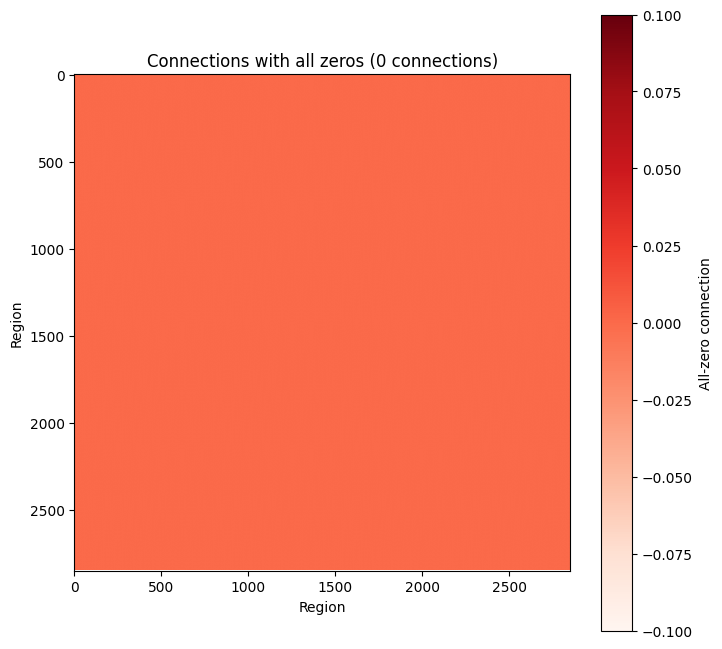

✅ No connections were found with all-zero values across subjects
✅ Detection and visualization of all-zero connections completed.



In [5]:
# === 3. Function to visualize connections with all zeros (raw data) ===
def plot_zero_connections(df_vectors, triu_idx):
    """
    Detect and visualize connections (i, j) that are zero across all subjects.
    Also prints a table with these connections.

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.
        triu_idx (tuple): Indices of upper triangle used in vectorization.

    Returns:
        zero_conn_indices (list): List of (i, j) pairs with all zeros.
    """
    # Detect connections (columns) where all subjects have zero
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    print(f"⚠️ Number of connections always zero: {len(zero_cols)}")

    # Map back to (i, j) pairs
    zero_conn_indices = [(triu_idx[0][col], triu_idx[1][col]) for col in zero_cols]

    # === Mask for visualization for all zero ===
    n = len(triu_idx[0]) + 1
    mask = np.zeros((n, n))
    for i, j in zero_conn_indices:
        mask[i, j] = 1
        mask[j, i] = 1  # Symmetric
    
    plt.figure(figsize=(8, 8))  # Size of the figure
    plt.imshow(mask, cmap="Reds")
    plt.title(f"Connections with all zeros ({len(zero_conn_indices)} connections)")
    plt.xlabel("Region")
    plt.ylabel("Region")  
    plt.colorbar(label="All-zero connection")
    plt.show() 
    
    # === Summary able ===
    if zero_conn_indices:
        df_zero = pd.DataFrame(zero_conn_indices, columns=['Region_i', 'Region_j'])
        print("\n🔍 Number of connections always zero:")
        print(df_zero)
    else:
        print("✅ No connections were found with all-zero values across subjects")

    print("✅ Detection and visualization of all-zero connections completed.\n")
    return zero_conn_indices

# Visualize connections "always zero" BEFORE pre-processing 
zero_conns = plot_zero_connections(gm_vectors, triu_idx)


## Median Imputation (Preserving All-Zero Columns)

This function imputes zero values in each connectivity column (connection) by the column-wise median, while preserving columns that are originally all zeros (i.e., connections that are morphologically absent across all subjects).

- **Function:** `impute_median_preserve_zeros(df_vectors)`
- **Input:** 
  - `df_vectors`: DataFrame of vectorized connectivity matrices.
- **Outputs:**
  - Imputed DataFrame with median-filled values.
  - List of columns that were originally all zeros.

**Key Features:**
- All-zero columns are temporarily removed and preserved without imputation.
- For other columns, zero values are replaced with the median of the non-zero values.
- The original column order is restored at the end.

Example usage:
```python
gm_vectors_median, zero_cols_median = impute_median_preserve_zeros(gm_vectors)


In [6]:
# === 4A. Imputation by median preserving zero columns ===
def impute_median_preserve_zeros(df_vectors):
    """
    Impute zeros by the median value of each connection (column),
    preserving columns that are originally all zeros.

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.

    Returns:
        DataFrame: Imputed matrices.
        list: Columns originally all zeros.
    """
    # Detect columns that are all zeros
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    num_zero_cols = len(zero_cols)
    print(f"⚠️ Columns with all zeros detected and preserved: {num_zero_cols}")

    # Remove those columns temporarily
    df_tmp = df_vectors.drop(columns=zero_cols)

    # Impute zeros by median for each column
    df_imputed = df_tmp.copy()
    for col in df_tmp.columns:
        non_zero = df_tmp[col][df_tmp[col] != 0]
        median = non_zero.median() if not non_zero.empty else 0
        df_imputed[col] = df_tmp[col].replace(0, median)

    # Add back the all-zero columns
    for col in zero_cols:
        df_imputed[col] = 0.0

    # Restore original column order
    df_imputed = df_imputed[df_vectors.columns]

    print(f"✅ Median imputation completed: {df_imputed.shape[1] - num_zero_cols} columns imputed, {num_zero_cols} all-zero columns preserved (total: {df_imputed.shape[1]} connections).")
  
    return df_imputed, zero_cols

# Apply median imputation preserving zeros
gm_vectors_median, zero_cols_median = impute_median_preserve_zeros(gm_vectors)
gm_vectors_median.head() # Check the first rows of the DataFrame


⚠️ Columns with all zeros detected and preserved: 0
✅ Median imputation completed: 2850 columns imputed, 0 all-zero columns preserved (total: 2850 connections).


,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
sub-0001,0.60113,0.55975,0.61223,0.61517,0.60027,0.60058,0.62330,0.59487,0.60575,0.60202,...,0.55579,0.54460,0.54330,0.55592,0.56246,0.56297,0.57248,0.54620,0.55940,0.55186
sub-0002,0.56575,0.55203,0.55987,0.58511,0.54836,0.58445,0.59911,0.57287,0.57586,0.57352,...,0.54266,0.53912,0.54804,0.54708,0.55177,0.55695,0.56130,0.55139,0.55500,0.55608
sub-0003,0.60039,0.59102,0.63098,0.61155,0.59582,0.59629,0.65306,0.60279,0.61388,0.61282,...,0.57695,0.59015,0.55148,0.58020,0.58538,0.54933,0.57912,0.55751,0.58903,0.55083
sub-0004,0.63335,0.60451,0.61414,0.61322,0.57930,0.61305,0.60627,0.59748,0.62667,0.59854,...,0.59110,0.58784,0.58174,0.58193,0.60018,0.59617,0.59492,0.59053,0.59101,0.58125
sub-0005,0.58443,0.56960,0.57106,0.59671,0.59034,0.60774,0.63375,0.57532,0.59936,0.59905,...,0.54789,0.54710,0.54188,0.55855,0.56122,0.55803,0.57589,0.55139,0.57375,0.56320


## KNN Imputation (Preserving All-Zero Columns)

This function imputes zero values using K-Nearest Neighbors (KNN), while preserving columns that are entirely zero across all subjects (representing morphologically absent connections).

- **Function:** `impute_knn_preserve_zeros(df_vectors, n_neighbors=5)`
- **Inputs:**
  - `df_vectors`: DataFrame of vectorized connectivity matrices.
  - `n_neighbors`: Number of neighbors used for KNN imputation.
- **Outputs:**
  - Imputed DataFrame with KNN-filled values.
  - List of columns that were originally all zeros.

**Key Features:**
- All-zero columns are preserved and excluded from the KNN imputation.
- Zero values in the remaining data are treated as missing (`NaN`) and imputed using KNN.
- The original structure and order of columns are preserved.

Example usage:
```python
gm_vectors_knn, zero_cols = impute_knn_preserve_zeros(gm_vectors, n_neighbors=5)


In [7]:
# === 4B. Imputation by KNN preserving zero columns ===
def impute_knn_preserve_zeros(df_vectors, n_neighbors=5):
    """
    Impute zeros using KNN, preserving columns that were originally all zeros.
    
    Args:
        df_vectors (DataFrame): Vectorized matrices.
        n_neighbors (int): Number of neighbors for KNN.

    Returns:
        DataFrame: Imputed matrices.
        list: Columns originally all zeros.
    """
     # Identify columns where all values are zero across subjects
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    num_zero_cols = len(zero_cols)
    print(f"⚠️ Columns with all zeros detected and preserved: {num_zero_cols}")
    
    # Temporarily remove all-zero columns from the dataset
    df_tmp = df_vectors.drop(columns=zero_cols)

    # Replace zeros with NaN for KNN imputation
    df_tmp = df_tmp.replace(0, np.nan)

    # Apply KNN imputation on remaining columns
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_array = imputer.fit_transform(df_tmp)

    # Convert the result back to a DataFrame
    df_imputed = pd.DataFrame(imputed_array, index=df_tmp.index, columns=df_tmp.columns)

    # Add back the previously removed all-zero columns, preserving them as 0.0
    for col in zero_cols:
        df_imputed[col] = 0.0

    # Restore original column order
    df_imputed = df_imputed[df_vectors.columns]

    print(f"✅ KNN imputation completed using {n_neighbors} neighbors: {df_imputed.shape[1] - num_zero_cols} columns imputed, {num_zero_cols} all-zero columns preserved (total: {df_imputed.shape[1]} connections).")
    
    return df_imputed, zero_cols

# Apply knn imputation preserving zeros
gm_vectors_knn, zero_cols = impute_knn_preserve_zeros(gm_vectors, n_neighbors=5)
gm_vectors_knn.head() # Check the first rows of the DataFrame


⚠️ Columns with all zeros detected and preserved: 0
✅ KNN imputation completed using 5 neighbors: 2850 columns imputed, 0 all-zero columns preserved (total: 2850 connections).


,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
sub-0001,0.60113,0.55975,0.61223,0.61517,0.60027,0.60058,0.62330,0.59487,0.60575,0.60202,...,0.55579,0.54460,0.54330,0.55592,0.56246,0.562970,0.57248,0.546200,0.55940,0.551860
sub-0002,0.56575,0.55203,0.55987,0.58511,0.54836,0.58445,0.59911,0.57287,0.57586,0.57352,...,0.54266,0.53912,0.54465,0.54708,0.55177,0.557048,0.56130,0.546242,0.55500,0.558682
sub-0003,0.60039,0.59102,0.63098,0.61155,0.59582,0.59629,0.65306,0.60279,0.61388,0.61282,...,0.57695,0.59015,0.55148,0.58020,0.58538,0.549330,0.57912,0.557510,0.58903,0.550830
sub-0004,0.63335,0.60451,0.61414,0.61322,0.57930,0.61305,0.60627,0.59748,0.62667,0.59854,...,0.59110,0.58784,0.58174,0.58193,0.60018,0.596170,0.59492,0.590530,0.59101,0.581250
sub-0005,0.58443,0.56960,0.57106,0.59671,0.59034,0.60774,0.63375,0.57532,0.59936,0.59905,...,0.54789,0.54710,0.54188,0.55855,0.56122,0.558030,0.57589,0.551390,0.57375,0.563200


In [8]:
 zero_cols = gm_vectors_median.columns[(gm_vectors_median == 0).all()]
 num_zero = len(zero_cols)
 print(f"⚠️ {num_zero} gm_vectors_median all-zero columns.")
 zero_cols = gm_vectors_knn.columns[(gm_vectors_knn == 0).all()]
 num_zero = len(zero_cols)
 print(f"⚠️ {num_zero} gm_vectors_knn all-zero columns.")

⚠️ 0 gm_vectors_median all-zero columns.
⚠️ 0 gm_vectors_knn all-zero columns.


## Covariate Correction (Linear Regression)

This function corrects each brain connection (column) in the vectorized connectivity matrix for covariates (e.g., age, sex) using linear regression. It returns the residuals of the regression, effectively removing the effect of the specified covariates. Columns that are entirely zero across all subjects are preserved and not corrected.

- **Function:** `correct_vectors_covariates(df_vectors, clinic_df, covariates=['age', 'sex'])`
- **Inputs:**
  - `df_vectors`: Vectorized connectivity matrix (`subjects × connections`)
  - `clinic_df`: Clinical DataFrame containing covariate information
  - `covariates`: List of covariates to correct for (degmult: `['age', 'sex']`)
- **Output:** DataFrame of covariate-corrected values (same shape as input)

**Key Features:**
- Automatically aligns subject indices between connectivity and clinical data.
- Skips columns that are all-zero.
- Applies linear regression to each connection individually.
- Replaces each value with its residual (i.e., covariate-adjusted value).

Example usage:
```python
gm_vectors_median_corrected = correct_vectors_covariates(gm_vectors_median, clinic_df)


In [9]:
# === 5. Covariate correction ===

def correct_vectors_covariates(df_vectors, clinic_df, covariates=['AGE', 'SEX'], verbose=True):
    """
    Correct each connection by covariates (e.g., age and sex) using linear regression.
    Preserves columns that are all zeros.

    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices (subjects x connections).
        clinic_df (DataFrame): Clinical data.
        covariates (list): List of covariate names.
        verbose (bool): Whether to print info messages.

    Returns:
        DataFrame: Covariate-corrected matrix (same shape as input).
    """
    # Subjects in common between clinical and connectivity data
    common_subjects = df_vectors.index.intersection(clinic_df.index)

    # Select covariates and drop rows with missing values
    df_covars = clinic_df.loc[common_subjects, covariates].dropna()

    # Align matrix to subjects with valid covariates
    df_vectors = df_vectors.loc[df_covars.index]

    if verbose:
        print(f"🔍 Subjects with corrected data: {len(df_vectors)}")
        print(f"🔍 Covariates shape: {df_covars.shape}")
        print(f"🔍 Common subject IDs: {list(df_covars.index)}")

    # Detect all-zero columns (to skip them)
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    if verbose:
        print(f"⚠️ Skipping covariate correction for {len(zero_cols)} all-zero columns.")

    # Work only on valid columns
    df_tmp = df_vectors.drop(columns=zero_cols)

    # === Check for NaNs before regression ===
    nan_check_cols = df_tmp.columns[df_tmp.isna().any()]
    if len(nan_check_cols) > 0:
        print(f"⚠️ Detected {len(nan_check_cols)} columns with NaN values BEFORE regression.")
        print("🔍 Columns with NaNs:", list(nan_check_cols[:10]), "..." if len(nan_check_cols) > 10 else "")    
    
    # Initialize corrected matrix with NaN values
    corrected = pd.DataFrame(index=df_vectors.index, columns=df_vectors.columns)

    # Apply linear regression per connection
    for col in df_tmp.columns:
        y = df_tmp[col].values
        X = df_covars.values
        model = LinearRegression().fit(X, y)
        residuals = y - model.predict(X)
        corrected[col] = residuals

    # Reinsert all-zero columns as 0.0
    for col in zero_cols:
        corrected[col] = 0.0

    # Ensure original column order
    corrected = corrected[df_vectors.columns]

    # === Check for columns that remain NaN ===
    nan_cols_final = corrected.columns[corrected.isna().all()]
    if len(nan_cols_final) > 0:
        print(f"⚠️ Warning: {len(nan_cols_final)} columns remain completely NaN after correction.")
        print("📌 Columns:", list(nan_cols_final[:10]), "..." if len(nan_cols_final) > 10 else "")

    print(f"✅ Covariate correction completed on {corrected.shape[1] - len(zero_cols)} columns. Preserved {len(zero_cols)} all-zero columns.")

    return corrected

# Apply covariate correlation preserving zeros
gm_vectors_median_corrected = correct_vectors_covariates(gm_vectors_median, clinic_df)
gm_vectors_knn_corrected = correct_vectors_covariates(gm_vectors_knn, clinic_df)

print(gm_vectors_median_corrected.head()) # Check the first rows of the DataFrame
gm_vectors_knn_corrected.head() # Check the first rows of the DataFrame

🔍 Subjects with corrected data: 105
🔍 Covariates shape: (105, 2)
🔍 Common subject IDs: ['sub-0001', 'sub-0002', 'sub-0003', 'sub-0004', 'sub-0005', 'sub-0006', 'sub-0007', 'sub-0008', 'sub-0009', 'sub-0010', 'sub-0011', 'sub-0012', 'sub-0013', 'sub-0014', 'sub-0015', 'sub-0016', 'sub-0017', 'sub-0018', 'sub-0019', 'sub-0020', 'sub-0021', 'sub-0022', 'sub-0023', 'sub-0024', 'sub-0025', 'sub-0026', 'sub-0027', 'sub-0028', 'sub-0029', 'sub-0030', 'sub-0031', 'sub-0032', 'sub-0033', 'sub-0034', 'sub-0035', 'sub-0036', 'sub-0037', 'sub-0038', 'sub-0039', 'sub-0040', 'sub-0041', 'sub-0042', 'sub-0043', 'sub-0044', 'sub-0045', 'sub-0046', 'sub-0047', 'sub-0048', 'sub-0049', 'sub-0050', 'sub-0051', 'sub-0052', 'sub-0053', 'sub-0054', 'sub-0055', 'sub-0056', 'sub-0057', 'sub-0058', 'sub-0059', 'sub-0060', 'sub-0061', 'sub-0062', 'sub-0063', 'sub-0064', 'sub-0065', 'sub-0066', 'sub-0067', 'sub-0068', 'sub-0069', 'sub-0070', 'sub-0071', 'sub-0072', 'sub-0073', 'sub-0074', 'sub-0075', 'sub-0076', 

,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
sub-0001,0.030851,-0.013865,0.024466,0.023552,0.027191,0.011491,0.027382,0.020016,0.026002,0.017527,...,-0.000495,-0.009188,-0.005706,-0.004022,0.001116,0.004715,0.002009,-0.006914,-0.003235,-0.006668
sub-0002,0.001014,-0.020334,-0.023253,0.001433,-0.016776,0.002606,0.005909,0.002286,0.002663,-0.001451,...,-0.008880,-0.013305,-0.002555,-0.009864,-0.003840,0.004008,-0.006000,-0.006319,-0.004998,0.006011
sub-0003,0.031568,0.016370,0.047201,0.030033,0.026811,0.014764,0.051308,0.029685,0.039634,0.036994,...,0.021637,0.032546,0.002408,0.019685,0.025766,-0.005518,0.007828,0.001712,0.022269,-0.002483
sub-0004,0.059779,0.029053,0.025848,0.023342,0.003100,0.024217,0.003461,0.020594,0.046077,0.013357,...,0.031776,0.029879,0.031229,0.019111,0.035609,0.036458,0.021233,0.034808,0.022926,0.022204
sub-0005,0.010897,-0.005836,-0.017226,0.006812,0.014176,0.018904,0.031021,-0.001542,0.018777,0.013875,...,-0.011399,-0.010812,-0.008614,-0.004236,-0.003313,-0.001665,0.002240,-0.004302,0.005729,0.004160


In [10]:
zero_cols = gm_vectors_median_corrected.columns[(gm_vectors_median_corrected == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} gm_vectors_median_corrected all-zero columns.")
zero_cols = gm_vectors_knn_corrected.columns[(gm_vectors_knn_corrected == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} gm_vectors_knn_corrected all-zero columns.")

print(gm_vectors_knn_corrected.shape) 

⚠️ 0 gm_vectors_median_corrected all-zero columns.
⚠️ 0 gm_vectors_knn_corrected all-zero columns.
(105, 2850)


## Normalization (Min-Max Scaling)

This function applies normalization to the vectorized connectivity matrices, transforming the values to a common scale using **Min-Max scaling**. Columns that are all-zero across subjects are preserved and excluded from the normalization process.

- **Function:** `normalize_vectors(df_vectors)`
- **Input:** 
  - `df_vectors`: DataFrame of vectorized connectivity matrices (`subjects × connections`)
- **Output:** Normalized DataFrame with values scaled between 0 and 1.

**Key Features:**
- All-zero columns are detected and skipped during scaling.
- Applies `MinMaxScaler` to remaining columns.
- Original column order is preserved.

Example usage:
```python
gm_vectors_median_corrected_norm = normalize_vectors(gm_vectors_median_corrected)


In [11]:
# === 6. Min-Max Normalization ===
def normalize_vectors(df_vectors):
    """
    Apply Min-Max normalization to vectorized connectivity matrices (subject x connection)
        
    Args:
        df_vectors (DataFrame): Vectorized connectivity matrices.

    Returns:
        DataFrame: Min-Max normalized data.
    """
    # Detect and remove all-zero columns
    zero_cols = df_vectors.columns[(df_vectors == 0).all()]
    num_zero = len(zero_cols)
    print(f"⚠️ Skipping normalization for {num_zero} all-zero columns.")

    df_tmp = df_vectors.drop(columns=zero_cols)

    # Z-score normalization on remaining data    
    #scaler = StandardScaler()
    #df_normalized = pd.DataFrame(
    #    scaler.fit_transform(df_tmp),
    #    index=df_tmp.index,
    #    columns=df_tmp.columns
    #)

    # Min-Max normalization on remaining data    
    scaler = MinMaxScaler()
    df_normalized = pd.DataFrame(
        scaler.fit_transform(df_tmp),
        index=df_tmp.index,
        columns=df_tmp.columns
    )

    

    # Add back the zero columns
    for col in zero_cols:
        df_normalized[col] = 0.0

    # Restore original column order
    df_normalized = df_normalized[df_vectors.columns]

    print(f"✅ Min-Max normalization completed on {df_normalized.shape[1] - num_zero} columns. Preserved {num_zero} all-zero columns.")
    return df_normalized

# Apply normalization to corrected data
gm_vectors_median_corrected_norm = normalize_vectors(gm_vectors_median_corrected)
gm_vectors_knn_corrected_norm = normalize_vectors(gm_vectors_knn_corrected)
print(gm_vectors_median_corrected_norm.head()) # Check the first rows of the DataFrame
gm_vectors_knn_corrected_norm.head() # Check the first rows of the DataFrame    

⚠️ Skipping normalization for 0 all-zero columns.
✅ Min-Max normalization completed on 2850 columns. Preserved 0 all-zero columns.
⚠️ Skipping normalization for 0 all-zero columns.
✅ Min-Max normalization completed on 2850 columns. Preserved 0 all-zero columns.
              0         1         2         3         4         5     \
sub-0001  0.688319  0.183972  0.512245  0.704117  0.723243  0.568133   
sub-0002  0.345745  0.131903  0.136111  0.484109  0.188836  0.479034   
sub-0003  0.675074  0.472755  0.695437  0.755022  0.691407  0.594435   
sub-0004  1.000000  0.580430  0.520711  0.694148  0.446428  0.688397   
sub-0005  0.474451  0.261875  0.176838  0.531982  0.573954  0.638911   

              6         7         8         9     ...      2840      2841  \
sub-0001  0.617915  0.592705  0.548331  0.608372  ...  0.313618  0.122890   
sub-0002  0.464010  0.385469  0.339478  0.378119  ...  0.105968  0.043818   
sub-0003  0.777405  0.670166  0.640241  0.795994  ...  0.698307  0.860252 

,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
sub-0001,0.689028,0.186447,0.511640,0.702728,0.703384,0.569558,0.614129,0.592459,0.545665,0.590714,...,0.335433,0.148159,0.093149,0.358899,0.371534,0.409291,0.466619,0.158969,0.317077,0.222837
sub-0002,0.368281,0.127222,0.130292,0.484931,0.211368,0.487091,0.465901,0.406301,0.349666,0.378576,...,0.177773,0.077231,0.170522,0.231700,0.297812,0.396139,0.335643,0.167639,0.291772,0.452317
sub-0003,0.696737,0.463274,0.693330,0.766551,0.699134,0.599939,0.779293,0.693987,0.660145,0.808320,...,0.751529,0.867166,0.292359,0.875085,0.738243,0.218878,0.561793,0.284751,0.683087,0.298570
sub-0004,1.000000,0.579392,0.522683,0.700664,0.433790,0.687680,0.449003,0.598533,0.714251,0.544107,...,0.942141,0.821215,1.000000,0.862575,0.884678,1.000000,0.780998,0.767402,0.692512,0.745405
sub-0005,0.474521,0.259960,0.178458,0.537894,0.557740,0.638366,0.639252,0.366102,0.484989,0.549897,...,0.130418,0.120180,0.021762,0.354233,0.305644,0.290573,0.470401,0.197054,0.445722,0.418820


In [12]:
zero_cols = gm_vectors_median_corrected_norm.columns[(gm_vectors_median_corrected_norm == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} all-zero columns.")
zero_cols = gm_vectors_knn_corrected_norm.columns[(gm_vectors_knn_corrected_norm == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} all-zero columns.")

print(gm_vectors_knn_corrected_norm.shape) 

⚠️ 0 all-zero columns.
⚠️ 0 all-zero columns.
(105, 2850)


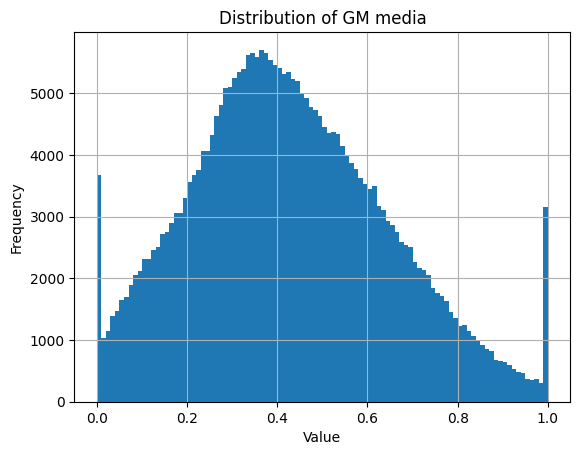

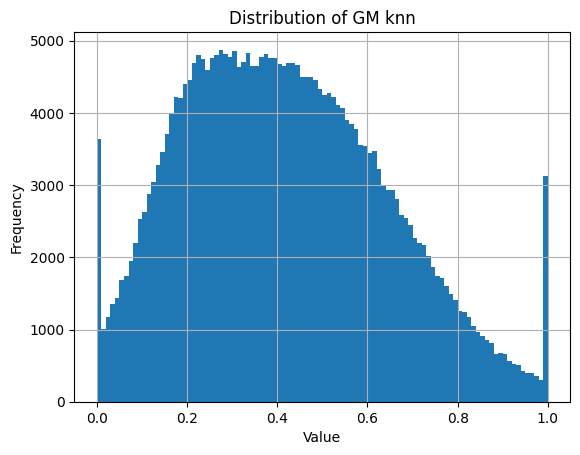

In [13]:
gm_vectors_median_corrected_norm.stack().hist(bins=100)
plt.title("Distribution of GM media")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

gm_vectors_knn_corrected_norm.stack().hist(bins=100)
plt.title("Distribution of GM knn")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## Harmonization Using ComBat (with Control Subjects)

This section applies ComBat harmonization to correct for batch effects (e.g., acquisition site) in the GM connectivity data. The process includes clinical covariates and control subjects, and excludes small batches to ensure stability.

### Steps Performed:

- **Assign batch labels** using the `SITE` variable derived from `redcap_event_name`. Control subjects are grouped into a single batch called `"control_batch"`.
- **Filter out batches** (`SITE`) with fewer than 3 subjects to avoid introducing NaNs.
- **Align data**: Ensure that both GM matrices and covariate data are aligned by subject ID.
- **Remove all-zero connections** from the matrices prior to harmonization.
- **Apply ComBat harmonization** using the `neuroHarmonize` package.
- **Restore all-zero columns** to the harmonized data (they are preserved as zeros).
- **Reorder columns** to match the original structure.

### Input:
- GM connectivity matrices (already normalized and covariate-corrected)
- Clinical data: `SITE`

### Output:
- `gm_vectors_median_combat`: Harmonized data after median imputation
- `gm_vectors_knn_combat`: Harmonized data after KNN imputation

**Example usage:**
```python
model_median, data_combat_median = harmonizationLearn(X_median_clean.values, covars_filtered)


In [14]:
# === 7. Harmonization using ComBat (including controls, safe version) ===
# Create 'SITE' column for batch
clinic_df['SITE'] = clinic_df['MR_DATE']
# Convert MR_DATE to datetime and extract the year
clinic_df['SITE'] = pd.to_datetime(clinic_df['MR_DATE'], errors='coerce').dt.year.astype(str)

print("✅ Batch distribution (after assigning to controls):")
print(clinic_df['SITE'].value_counts())

# Align subjects between clinical data and GM matrix
common_ids = gm_vectors_median_corrected_norm.index.intersection(clinic_df.index)

# Prepare covariates and drop subjects with missing values
#covars = clinic_df.loc[common_ids, ['SITE', 'age', 'sex', 'controls_ms']].dropna()
#covars = clinic_df.loc[common_ids, ['SITE', 'AGE', 'SEX', 'GROUP']].dropna()
covars = clinic_df.loc[common_ids, ['SITE']].dropna()

# 🧹 Remove SITE batches with <3 subjects (to prevent NaNs)
site_counts = covars['SITE'].value_counts()
valid_sites = site_counts[site_counts >= 3].index
invalid_sites = site_counts[site_counts < 3].index
print(f"⚠️ Excluding {len(invalid_sites)} SITE(s) with <3 subjects: {invalid_sites.tolist()}")

covars_filtered = covars[covars['SITE'].isin(valid_sites)]
print(f"👥 Subjects before ComBat: {len(covars)} → after filtering: {len(covars_filtered)} (removed: {len(covars) - len(covars_filtered)})")
# 🧹 Remove covariates with constant values (to avoid singular matrix)
covars_filtered = covars_filtered.loc[:, covars_filtered.nunique() > 1]
print(f"🧼 Covariates retained after removing constants: {list(covars_filtered.columns)}")


# Align GM matrices to filtered covariates
X_median = gm_vectors_median_corrected_norm.loc[covars_filtered.index]
X_knn = gm_vectors_knn_corrected_norm.loc[covars_filtered.index]

# === Detect and remove all-zero columns ===
zero_cols_median = X_median.columns[(X_median == 0).all()]
zero_cols_knn = X_knn.columns[(X_knn == 0).all()]
print(f"⚠️ Median version: {len(zero_cols_median)} all-zero columns excluded from ComBat")
print(f"⚠️ KNN version: {len(zero_cols_knn)} all-zero columns excluded from ComBat")

X_median_clean = X_median.drop(columns=zero_cols_median)
X_knn_clean = X_knn.drop(columns=zero_cols_knn)

# === Apply ComBat ===
model_median, data_combat_median = harmonizationLearn(X_median_clean.values, covars_filtered)
gm_vectors_median_combat = pd.DataFrame(data_combat_median,
                                        index=covars_filtered.index,
                                        columns=X_median_clean.columns)

model_knn, data_combat_knn = harmonizationLearn(X_knn_clean.values, covars_filtered)
gm_vectors_knn_combat = pd.DataFrame(data_combat_knn,
                                     index=covars_filtered.index,
                                     columns=X_knn_clean.columns)

# === Add back all-zero columns ===
for col in zero_cols_median:
    gm_vectors_median_combat[col] = 0.0
for col in zero_cols_knn:
    gm_vectors_knn_combat[col] = 0.0

# Restore original column order
gm_vectors_median_combat = gm_vectors_median_combat[X_median.columns]
gm_vectors_knn_combat = gm_vectors_knn_combat[X_knn.columns]

print("✅ ComBat harmonization completed for both Median and KNN imputations (controls included).")

print(gm_vectors_median_combat.head()) # Check the first rows of the DataFrame
print(gm_vectors_knn_combat.shape) 
gm_vectors_knn_combat.head() # Check the first rows of the DataFrame    

✅ Batch distribution (after assigning to controls):
SITE
2016    64
2017    38
2018     3
Name: count, dtype: int64
⚠️ Excluding 0 SITE(s) with <3 subjects: []
👥 Subjects before ComBat: 105 → after filtering: 105 (removed: 0)
🧼 Covariates retained after removing constants: ['SITE']
⚠️ Median version: 0 all-zero columns excluded from ComBat
⚠️ KNN version: 0 all-zero columns excluded from ComBat
✅ ComBat harmonization completed for both Median and KNN imputations (controls included).
              0         1         2         3         4         5     \
sub-0001  0.720764  0.216543  0.545049  0.730185  0.746932  0.599820   
sub-0002  0.372614  0.165774  0.165229  0.520219  0.224949  0.514323   
sub-0003  0.609230  0.425289  0.621703  0.700938  0.637341  0.530722   
sub-0004  0.909335  0.534252  0.458456  0.635352  0.392330  0.630247   
sub-0005  0.503414  0.292500  0.206355  0.565907  0.601113  0.667735   

              6         7         8         9     ...      2840      2841  \
su

,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
sub-0001,0.724195,0.224187,0.547670,0.733817,0.731081,0.604871,0.648417,0.622064,0.580970,0.629043,...,0.382357,0.185829,0.124462,0.414545,0.411437,0.439847,0.507344,0.183380,0.356848,0.249406
sub-0002,0.402965,0.166656,0.164689,0.525382,0.250996,0.525649,0.506614,0.440680,0.386219,0.422066,...,0.222299,0.113730,0.205646,0.291864,0.339094,0.426272,0.380920,0.191946,0.331799,0.480343
sub-0003,0.621625,0.408361,0.612018,0.705208,0.639485,0.531903,0.724996,0.632192,0.584045,0.734054,...,0.645359,0.757384,0.231123,0.785679,0.665537,0.190696,0.493810,0.246536,0.614174,0.263159
sub-0004,0.907244,0.526469,0.452341,0.634953,0.374864,0.624345,0.372384,0.536372,0.635931,0.470245,...,0.821355,0.715314,0.844703,0.772938,0.810483,0.884385,0.720348,0.712741,0.623401,0.676592
sub-0005,0.509365,0.295597,0.213061,0.576069,0.588969,0.670971,0.672452,0.401512,0.520681,0.589219,...,0.174224,0.157389,0.049557,0.410045,0.346779,0.317318,0.510996,0.221005,0.484188,0.446633


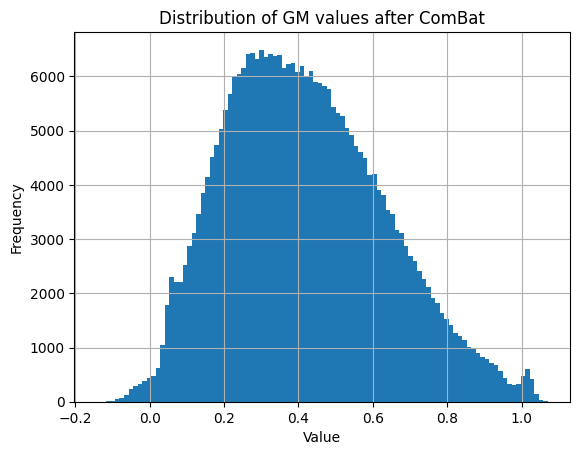

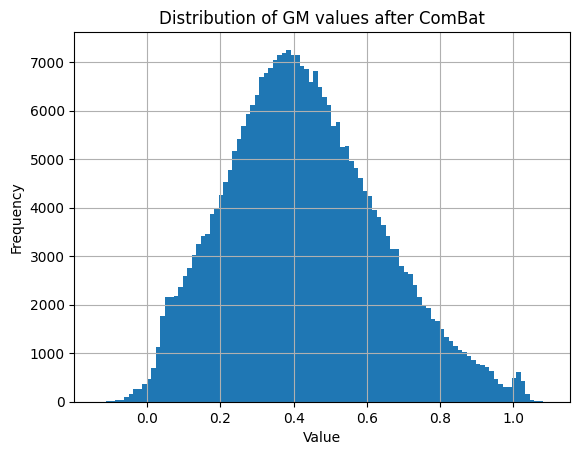

In [15]:
gm_vectors_knn_combat.stack().hist(bins=100)
plt.title("Distribution of GM values after ComBat")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

gm_vectors_median_combat.stack().hist(bins=100)
plt.title("Distribution of GM values after ComBat")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## Re-normalization After ComBat (Min-Max Scaling)

After ComBat harmonization, some connection values may gmll outside the original [0, 1] range, including negative values. To ensure compatibility with downstream machine learning models (e.g., GNNs), this step re-applies **Min-Max scaling** to normalize all features between 0 and 1.

- **Function:** `re_normalize_after_combat(df)`
- **Input:** DataFrame of ComBat-harmonized connectivity values.
- **Output:** Re-normalized DataFrame with values in [0, 1].

**Why it's necessary:**
- ComBat adjusts for batch effects but is not bounded by the original data range.
- GNNs and other ML models benefit from consistent input ranges.

**Example usage:**
```python
gm_vectors_median_combat = re_normalize_after_combat(gm_vectors_median_combat)
gm_vectors_knn_combat = re_normalize_after_combat(gm_vectors_knn_combat)


In [16]:
def re_normalize_after_combat(df):
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df),
        index=df.index,
        columns=df.columns
    )
    return df_scaled

# Re-normalize median and knn versions after ComBat
gm_vectors_median_combat_re = re_normalize_after_combat(gm_vectors_median_combat)
gm_vectors_knn_combat_re = re_normalize_after_combat(gm_vectors_knn_combat)


In [17]:
zero_cols = gm_vectors_median_combat.columns[(gm_vectors_median_combat == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} all-zero columns.")
zero_cols = gm_vectors_knn_combat.columns[(gm_vectors_knn_combat == 0).all()]
num_zero = len(zero_cols)
print(f"⚠️ {num_zero} all-zero columns.")

print(gm_vectors_median_combat.shape) 

⚠️ 0 all-zero columns.
⚠️ 0 all-zero columns.
(105, 2850)


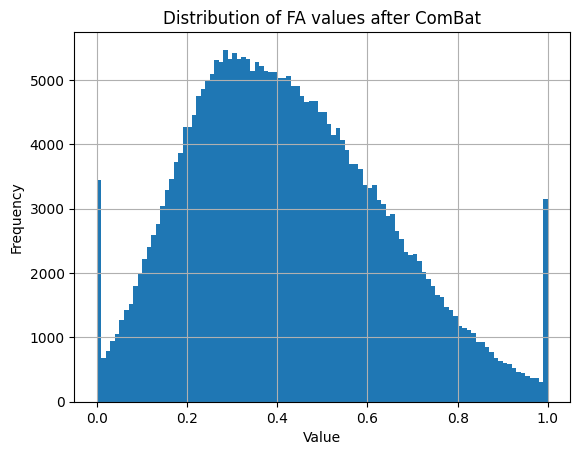

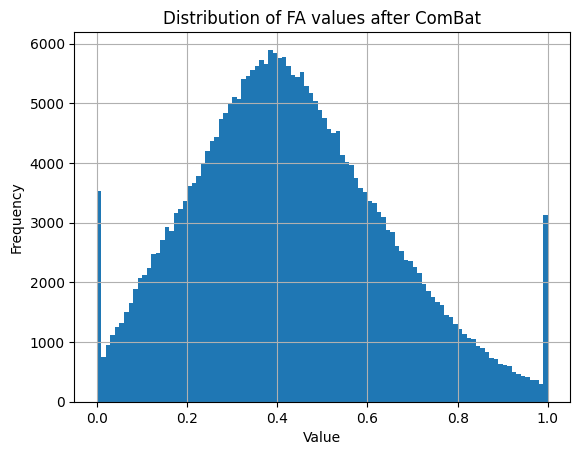

In [18]:
gm_vectors_knn_combat_re.stack().hist(bins=100)
plt.title("Distribution of FA values after ComBat")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

gm_vectors_median_combat_re.stack().hist(bins=100)
plt.title("Distribution of FA values after ComBat")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## Mask Weak Connections (Based on Control Subjects)

This function masks (sets to zero) brain connections that are weak in the majority of control subjects. A connection is considered weak if its value is below a specified threshold in more than a given proportion of controls. This helps remove noisy or unreliable connections before further analysis.

- **Function:** `mask_weak_connections(vectors_df, clinic_df, threshold=0.1, max_ratio=0.6)`
- **Inputs:**
  - `vectors_df`: DataFrame of vectorized connectivity matrices.
  - `clinic_df`: Clinical data containing a `controls_ms` column (0 = control).
  - `threshold`: Minimum value to consider a connection strong.
  - `max_ratio`: Maximum allowable proportion of controls with weak connections.
- **Outputs:**
  - `vectors_masked`: DataFrame with weak connections zeroed out.
  - `to_mask`: List of columns (connections) that were masked.
  - `zero_cols_after_masking`: Columns that became completely zero after masking.

### Process:
- Identifies control subjects.
- Computes the proportion of controls with values < `threshold` per connection.
- If this proportion exceeds `max_ratio`, the connection is masked (set to 0.0) in **all** subjects.
- Tracks columns that became entirely zero as a result.

**Example usage:**
```python
gm_vectors_median_combat_masked, masked_median, zero_median = mask_weak_connections(
    gm_vectors_median_combat, clinic_df, threshold=0.1, max_ratio=0.6)


In [19]:
# === 8. Mask weak connections (with zero-column detection) ===

def mask_weak_connections(vectors_df, clinic_df, threshold=0.1, max_ratio=0.6):
    """
    Mask connections where > max_ratio of controls have values below a threshold.
    Replaces those columns with zeros (instead of removing them).
    Also detects columns that are completely zero after masking.

    Args:
        vectors_df (DataFrame): Matrix of vectorized connectomes (subjects x connections).
        clinic_df (DataFrame): DataFrame with 'controls_ms' column.
        threshold (float): Weak connection threshold.
        max_ratio (float): Max proportion of controls allowed below threshold.

    Returns:
        vectors_masked (DataFrame): Same shape as input, with weak connections masked to 0.0
        to_mask (list): List of columns that were masked
        zero_cols_after_masking (list): Columns that became all-zero
    """
    # Identify controls
    control_ids = clinic_df[clinic_df['GROUP_MS'] == 0].index
    controls_matrix = vectors_df.loc[vectors_df.index.intersection(control_ids)]

    # Calculate proportion of controls below threshold per connection
    weak_ratio = (controls_matrix < threshold).sum(axis=0) / len(controls_matrix)
    to_mask = weak_ratio[weak_ratio > max_ratio].index

    print(f"⚠️ Masked {len(to_mask)} weak connections (threshold < {threshold} in > {int(max_ratio*100)}% of controls)")

    # Apply masking (zero out columns)
    vectors_masked = vectors_df.copy()
    for col in to_mask:
        vectors_masked[col] = 0.0

    # Check for columns that are now all-zero
    zero_cols_after_masking = vectors_masked.columns[(vectors_masked == 0).all()]
    print(f"🧯 Columns now completely zero after masking: {len(zero_cols_after_masking)}")

    return vectors_masked, list(to_mask), list(zero_cols_after_masking)

# Apply masking to ComBat-corrected matrices
gm_vectors_median_combat_masked_re, masked_median, zero_median = mask_weak_connections(
    gm_vectors_median_combat_re, clinic_df, threshold=0.1, max_ratio=0.6)

gm_vectors_knn_combat_masked_re, masked_knn, zero_knn = mask_weak_connections(
    gm_vectors_knn_combat_re, clinic_df, threshold=0.1, max_ratio=0.6)

gm_vectors_median_combat_masked, masked_median, zero_median = mask_weak_connections(
    gm_vectors_median_combat, clinic_df, threshold=0.1, max_ratio=0.6)

gm_vectors_knn_combat_masked, masked_knn, zero_knn = mask_weak_connections(
    gm_vectors_knn_combat, clinic_df, threshold=0.1, max_ratio=0.6)

⚠️ Masked 0 weak connections (threshold < 0.1 in > 60% of controls)
🧯 Columns now completely zero after masking: 0
⚠️ Masked 0 weak connections (threshold < 0.1 in > 60% of controls)
🧯 Columns now completely zero after masking: 0
⚠️ Masked 0 weak connections (threshold < 0.1 in > 60% of controls)
🧯 Columns now completely zero after masking: 0
⚠️ Masked 0 weak connections (threshold < 0.1 in > 60% of controls)
🧯 Columns now completely zero after masking: 0


## Reconstruct and Save Corrected Connectivity Matrices

This function reconstructs full symmetric connectivity matrices (e.g., 76×76) from the vectorized format and saves each subject's corrected matrix as a `.csv` file.

- **Function:** `reconstruct_and_save(corrected_vectors, original_triu_idx, output_dir, n_nodes=76)`
- **Inputs:**
  - `corrected_vectors`: DataFrame of corrected vectorized matrices (`subjects × connections`)
  - `original_triu_idx`: Tuple of indices used during vectorization (upper triangle)
  - `output_dir`: Path where the reconstructed matrices will be saved
  - `n_nodes`: Number of brain regions (nodes) per matrix (degmult: 76)

### Process:
- Initializes a zero-filled vector for each subject's connections.
- Reconstructs the full symmetric matrix using the upper triangle indices.
- Saves each matrix to a `.csv` file named `{subject_id}_GM_corrected.csv`.

**Example usage:**
```python
reconstruct_and_save(
    corrected_vectors=gm_vectors_median_combat,
    original_triu_idx=triu_idx,
    output_dir="path/to/save_dir",
    n_nodes=76
)


In [20]:
# === 9A. Reconstruct and save corrected matrices ===
def reconstruct_and_save(corrected_vectors, original_triu_idx, output_dir, n_nodes=76):
    """
    Reconstruct and save corrected connectivity matrices preserving the original shape (n_nodes x n_nodes).

    Args:
        corrected_vectors (DataFrame): Corrected vectorized matrices.
        original_triu_idx (tuple): Indices of upper triangle used in vectorization.
        output_dir (str): Path to save the corrected matrices.
        n_nodes (int): Number of nodes in the connectivity matrices.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Number of unique connections (upper triangle)
    total_connections = len(original_triu_idx[0])

    # Process each subject individually
    for subj in corrected_vectors.index:
        # Initialize full connection vector (including any missing positions as zero)
        full_vector = np.zeros(total_connections)
        valid_cols = [col for col in corrected_vectors.columns]
        full_vector[valid_cols] = corrected_vectors.loc[subj].values

        # Reconstruct full symmetric matrix
        matrix = np.zeros((n_nodes, n_nodes))
        matrix[original_triu_idx] = full_vector
        matrix = matrix + matrix.T # make it symmetric

        # Save the matrix to CSV
        output_path = os.path.join(output_dir, f"{subj}_GM_corrected.csv")
        pd.DataFrame(matrix).to_csv(output_path, index=False, header=False)

    print(f"✅ Corrected matrices saved in: {output_dir}")

# Save corrected matrices
reconstruct_and_save(
    corrected_vectors=gm_vectors_median_combat_masked,
    original_triu_idx=triu_idx,
    output_dir="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_median",
    n_nodes=76 # Dimensions of the matrix (76x76) - Original and corrected   
)

reconstruct_and_save(
    corrected_vectors=gm_vectors_knn_combat_masked,
    original_triu_idx=triu_idx,
    output_dir="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_knn",
    n_nodes=76 # Dimensions of the matrix (76x76) - Original and corrected
)

reconstruct_and_save(
    corrected_vectors=gm_vectors_median_combat_masked_re,
    original_triu_idx=triu_idx,
    output_dir="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_median_re",
    n_nodes=76 # Dimensions of the matrix (76x76) - Original and corrected   
)

reconstruct_and_save(
    corrected_vectors=gm_vectors_knn_combat_masked_re,
    original_triu_idx=triu_idx,
    output_dir="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_knn_re",
    n_nodes=76 # Dimensions of the matrix (76x76) - Original and corrected
)

✅ Corrected matrices saved in: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_median
✅ Corrected matrices saved in: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_knn
✅ Corrected matrices saved in: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_median_re
✅ Corrected matrices saved in: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/corrected_GM_matrices_knn_re


## Compute and Visualize Group Mean Connectivity Matrices (Pre-Correction)

This step computes and visualizes the **mean connectivity matrix** separately for control and patient groups using the raw morphological connectivity matrices (before correction or harmonization).

### Functions:
- **`compute_group_mean_matrices(matrices_dict, clinic_df)`**  
  Calculates the mean connectivity matrix for each group (controls and patients), based on the clinical `controls_ms` label (0 = control, 1 = patient).

- **`plot_mean_matrix(matrix, title)`**  
  Displays a heatmap of a mean connectivity matrix using `matplotlib`.

- **`save_mean_matrix(matrix, output_path)`**  
  Saves the mean matrix to a CSV file.

### Outputs:
- Mean matrices for controls and patients (`mean_control`, `mean_patient`)
- Visual comparison of the two groups via heatmaps
- Saved `.csv` files for documentation or further analysis

### Example usage:
```python
mean_control, mean_patient = compute_group_mean_matrices(gm_matrices, clinic_df)
plot_mean_matrix(mean_control, "Mean Connectivity - Controls")
plot_mean_matrix(mean_patient, "Mean Connectivity - Patients")
save_mean_matrix(mean_control, "GM_mean_connectivity_controls_before.csv")
save_mean_matrix(mean_patient, "GM_mean_connectivity_patients_before.csv")


✅ Nº controls: 53
✅ Nº patients: 52


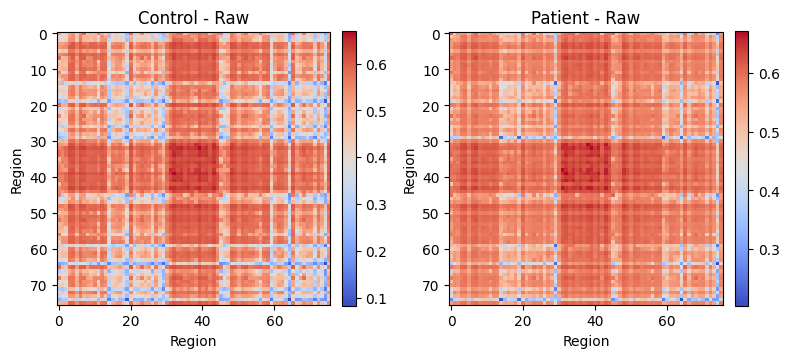

✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_mean_connectivity_controls_before.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_mean_connectivity_patients_before.csv


In [21]:
# === 9B. Compute and visualize mean matrices by group (control - patient BEFORE correction) ===
def compute_group_mean_matrices(matrices_dict, clinic_df):
    """
    Compute the mean connectivity matrix for controls and patients separately.

    Args:
        matrices_dict (dict): Dictionary {subject_id: connectivity matrix}.
        clinic_df (DataFrame): Clinical data with 'controls_ms' column (0=control, 1=patient).

    Returns:
        mean_control (np.ndarray): Mean matrix for controls.
        mean_patient (np.ndarray): Mean matrix for patients.
    """
    # Get subject IDs per group
    control_ids = clinic_df[clinic_df['GROUP'] == 0].index
    patient_ids = clinic_df[clinic_df['GROUP'] == 1].index

    # Extract matrices per group
    control_matrices = [matrices_dict[subj] for subj in control_ids if subj in matrices_dict]
    patient_matrices = [matrices_dict[subj] for subj in patient_ids if subj in matrices_dict]

    # Compute mean matrices
    mean_control = np.mean(control_matrices, axis=0)
    mean_patient = np.mean(patient_matrices, axis=0)  

    print(f"✅ Nº controls: {len(control_matrices)}")
    print(f"✅ Nº patients: {len(patient_matrices)}")

    return mean_control, mean_patient

def plot_multiple_matrices_grid(matrices, titles, cmap='coolwarm', n_cols=2):
    """
    Plot multiple connectivity matrices in a grid with a configurable number of columns.

    Args:
        matrices (list of np.ndarray): List of matrices to display.
        titles (list of str): Corresponding titles for each matrix.
        cmap (str): Colormap for the heatmaps.
        n_cols (int): Number of columns in the plot grid (default: 2).
    """
    assert len(matrices) == len(titles), "Length of matrices and titles must match"

    n = len(matrices)
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

    # If there's only one row, ensure axes is a 1D array
    if n_rows == 1:
        axes = np.array(axes).reshape(1, -1)
    elif n_cols == 1:
        axes = np.array(axes).reshape(-1, 1)

    axes = axes.flatten()

    for i, (matrix, title) in enumerate(zip(matrices, titles)):
        ax = axes[i]
        im = ax.imshow(matrix, cmap=cmap, vmin=np.min(matrix), vmax=np.max(matrix))
        ax.set_title(title)
        ax.set_xlabel("Region")
        ax.set_ylabel("Region")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show() 

def save_mean_matrix(matrix, output_path):
    """
    Save the mean matrix to CSV.
    
    Args:
        matrix (np.ndarray): Matrix to save.
        output_path (str): File path to save the CSV.
    """
    pd.DataFrame(matrix).to_csv(output_path, index=False, header=False)
    print(f"✅ Mean matrix saved to: {output_path}")

# Execution calculation, visualization and saving   
# Compute mean matrices for controls and patients
mean_control, mean_patient = compute_group_mean_matrices(gm_matrices, clinic_df)

# Visualization
plot_multiple_matrices_grid(
    matrices=[mean_control,
               mean_patient],
    titles=[
        "Control - Raw", 
        "Patient - Raw"],
        n_cols=2
)

# Save mean matrices
save_mean_matrix(mean_control, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_mean_connectivity_controls_before.csv")
save_mean_matrix(mean_patient, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_mean_connectivity_patients_before.csv")


## Compute and Visualize Group Mean Connectivity Matrices (Post-Correction)

This step reconstructs and visualizes the **mean corrected connectivity matrices** for control and patient groups, using data that has been imputed, covariate-corrected, batch-harmonized (ComBat), re-normalized, and optionally masked.

### Function: `compute_group_mean_corrected`
Reconstructs symmetric connectivity matrices from the corrected vectorized format and computes the mean matrix separately for controls and patients.

- **Inputs:**
  - `corrected_vectors`: DataFrame of corrected and masked vectorized matrices.
  - `original_triu_idx`: Upper triangle indices used during vectorization.
  - `clinic_df`: Clinical data with group labels (column `'GROUP'`: 0 = control, 1 = patient).
  - `n_nodes`: Size of the connectivity matrix (degmult: 76).

- **Outputs:**
  - `mean_control`: Mean connectivity matrix for controls.
  - `mean_patient`: Mean connectivity matrix for patients.

### Visualization and Export:
- Uses `plot_mean_matrix()` to visualize the mean matrices.
- Saves the resulting matrices to `.csv` files for future use or documentation.

**Example usage:**
```python
mean_control_median, mean_patient_median = compute_group_mean_corrected(
    corrected_vectors=gm_vectors_median_combat_masked,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)

plot_mean_matrix(mean_control_median, "Mean Corrected (Median) - Controls")
plot_mean_matrix(mean_patient_median, "Mean Corrected (Median) - Patients")

save_mean_matrix(mean_control_median, "GM_mean_corrected_controls_median.csv")


✅ Nº controls (corrected): 53
✅ Nº patients (corrected): 52
✅ Nº controls (corrected): 53
✅ Nº patients (corrected): 52
✅ Nº controls (corrected): 53
✅ Nº patients (corrected): 52
✅ Nº controls (corrected): 53
✅ Nº patients (corrected): 52


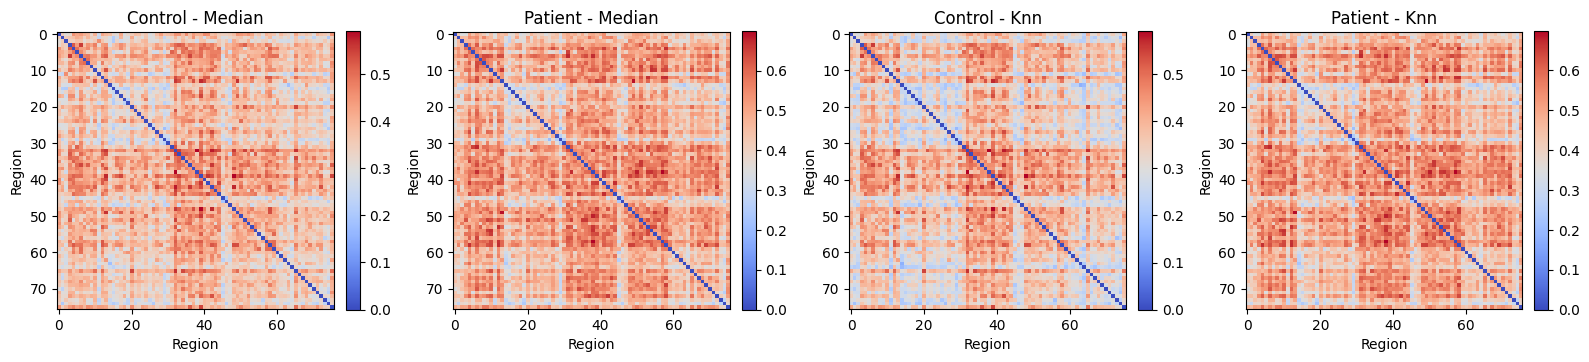

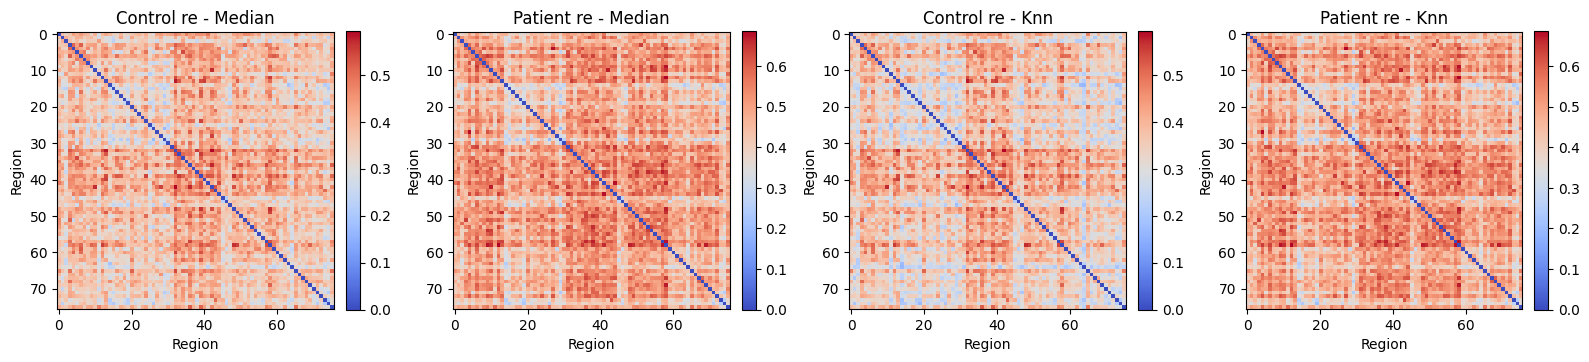

✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_median.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_median.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_knn.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_knn.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_median_re.csv
✅ Mean matrix saved to: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_median_re.csv
✅ Mean mat

In [22]:

# === 9C. Compute and visualize mean matrices AFTER correction ===
def compute_group_mean_corrected(corrected_vectors, original_triu_idx, clinic_df, n_nodes=76):
    """
    Compute the mean corrected connectivity matrix for controls and patients separately.

    Args:
        corrected_vectors (DataFrame): Corrected vectorized matrices.
        original_triu_idx (tuple): Upper triangle indices.
        clinic_df (DataFrame): Clinical data with 'controls_ms' column.
        n_nodes (int): Matrix size.

    Returns:
        mean_control (np.ndarray): Mean matrix for controls.
        mean_patient (np.ndarray): Mean matrix for patients.
    """
    # Get subject IDs per group
    control_ids = clinic_df[clinic_df['GROUP'] == 0].index
    patient_ids = clinic_df[clinic_df['GROUP'] == 1].index

    # Reconstruct matrices per subject
    matrices_control = []
    matrices_patient = []

    total_connections = len(original_triu_idx[0])

    for subj in corrected_vectors.index:
        # Build full connection vector (including zero-filled positions if needed)
        full_vector = np.zeros(total_connections)
        valid_cols = [col for col in corrected_vectors.columns]
        full_vector[valid_cols] = corrected_vectors.loc[subj].values

        # Reconstruct full matrix
        matrix = np.zeros((n_nodes, n_nodes))
        matrix[original_triu_idx] = full_vector
        matrix = matrix + matrix.T

         # Assign to group
        if subj in control_ids:
            matrices_control.append(matrix)
        elif subj in patient_ids:
            matrices_patient.append(matrix)

    # Compute mean matrices
    mean_control = np.mean(matrices_control, axis=0)
    mean_patient = np.mean(matrices_patient, axis=0)

    print(f"✅ Nº controls (corrected): {len(matrices_control)}")
    print(f"✅ Nº patients (corrected): {len(matrices_patient)}")

    return mean_control, mean_patient

#  Execution calculation, visualization and saving 
# Compute mean matrices for controls and patients (median & knn corrected)
mean_control_median, mean_patient_median = compute_group_mean_corrected(
    corrected_vectors=gm_vectors_median_combat_masked,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)
mean_control_knn, mean_patient_knn = compute_group_mean_corrected(
    corrected_vectors=gm_vectors_knn_combat_masked,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)

mean_control_median_re, mean_patient_median_re = compute_group_mean_corrected(
    corrected_vectors=gm_vectors_median_combat_masked_re,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)
mean_control_knn_re, mean_patient_knn_re = compute_group_mean_corrected(
    corrected_vectors=gm_vectors_knn_combat_masked_re,
    original_triu_idx=triu_idx,
    clinic_df=clinic_df,
    n_nodes=76
)

# Visualization
plot_multiple_matrices_grid(
    matrices=[mean_control_median,mean_patient_median,mean_control_knn,mean_patient_knn],
    titles=["Control - Median", "Patient - Median","Control - Knn", "Patient - Knn"],
        n_cols=4
)
plot_multiple_matrices_grid(
    matrices=[mean_control_median_re,mean_patient_median_re,mean_control_knn_re,mean_patient_knn_re],
    titles=["Control re - Median", "Patient re - Median","Control re - Knn", "Patient re - Knn"],
        n_cols=4
)

#  Save  matrices 
save_mean_matrix(mean_control_median, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_median.csv")
save_mean_matrix(mean_patient_median, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_median.csv")
save_mean_matrix(mean_control_knn, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_knn.csv")
save_mean_matrix(mean_patient_knn, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_knn.csv")

save_mean_matrix(mean_control_median_re, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_median_re.csv")
save_mean_matrix(mean_patient_median_re, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_median_re.csv")
save_mean_matrix(mean_control_knn_re, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_controls_knn_re.csv")
save_mean_matrix(mean_patient_knn_re, "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_corrected_patients_knn_re.csv")

## Demographic and Clinical Stratification (Age / Sex)

This section compares the demographic characteristics (age and sex) between the control and patient groups. It performs statistical tests to detect significant group differences and visualizes the distributions.

### Statistical Tests:
- **Age:** Independent two-sample *t*-test (Welch's t-test) is used to compare the age distributions between controls and patients.
- **Sex:** Chi-squared test is used to assess differences in sex proportions between the two groups.

### Visualizations:
- **Boxplot:** Shows the distribution of age by group.
- **Countplot:** Displays the number of males and females in each group.

**Example outputs:**
- `p_age`: *p*-value for the age difference.
- `p_sex`: *p*-value for the sex distribution difference.

**Example code:**
```python
t_stat, p_age = ttest_ind(controls['age'], patients['age'], equal_var=False)
chi2, p_sex, _, _ = chi2_contingency(pd.crosstab(clinic_df['controls_ms'], clinic_df['sex']))


🧠 Age - t-test p-value = 0.6148
🧠 Sex - chi-squared p-value = 0.7364


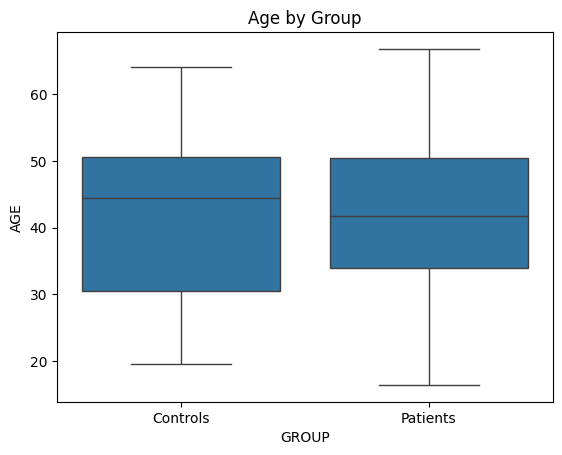

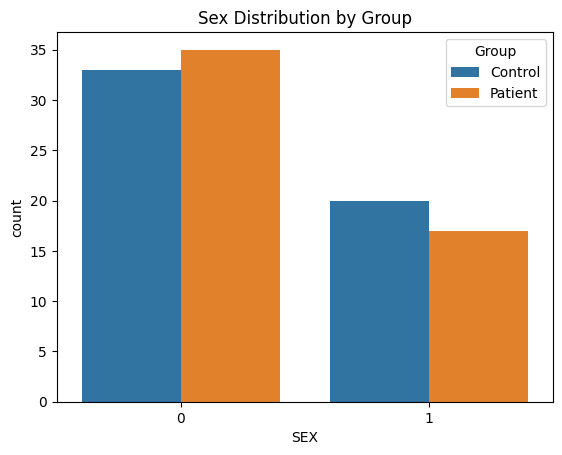

In [23]:
# === 10A. Demographic and clinical stratification (Age / Sex) ===

# Split data by group
controls = clinic_df[clinic_df['GROUP'] == 0]
patients = clinic_df[clinic_df['GROUP'] == 1]

# Age: t-test
t_stat, p_age = ttest_ind(controls['AGE'].dropna(), patients['AGE'].dropna(), equal_var=False)
print(f"🧠 Age - t-test p-value = {p_age:.4f}")

# Sex: chi-square
sex_table = pd.crosstab(clinic_df['GROUP'], clinic_df['SEX'])
chi2, p_sex, _, _ = chi2_contingency(sex_table)
print(f"🧠 Sex - chi-squared p-value = {p_sex:.4f}")

# Boxplot age
sns.boxplot(x='GROUP', y='AGE', data=clinic_df)
plt.xticks([0, 1], ['Controls', 'Patients'])
plt.title("Age by Group")
plt.show()

# Count sex
sns.countplot(x='SEX', hue='GROUP', data=clinic_df)
plt.legend(title='Group', labels=['Control', 'Patient'])
plt.title("Sex Distribution by Group")
plt.show()


## Clinical Stratification: Disease Duration (DD) and Disability (EDSS)

This section analyzes clinical variability **within the patient group** by stratifying them based on disease duration (`dd`) and exploring differences in disability scores (`EDSS`).

### Steps:
- **Disease Duration Binning:** Patients are categorized into 5 groups based on `dd` (disease duration in years):
  - `<2`, `2–5`, `5–10`, `10–20`, `20+`
- **Group Count:** Displays the number of patients in each duration group.
- **Visualization:** A boxplot shows how `EDSS` (disability score) varies across different `dd` groups.

### Example Code:
```python
bins = [0, 2, 5, 10, 20, 100]
labels = ['<2', '2–5', '5–10', '10–20', '20+']
patients['dd_grp'] = pd.cut(patients['dd'], bins=bins, labels=labels)

sns.boxplot(x='dd_grp', y='edss', data=patients)


C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\2369335701.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients['dd_grp'] = pd.cut(patients['DD'], bins=bins, labels=labels)


dd_grp
5–10     19
10–20    14
20+      13
<2        3
2–5       3
Name: count, dtype: int64


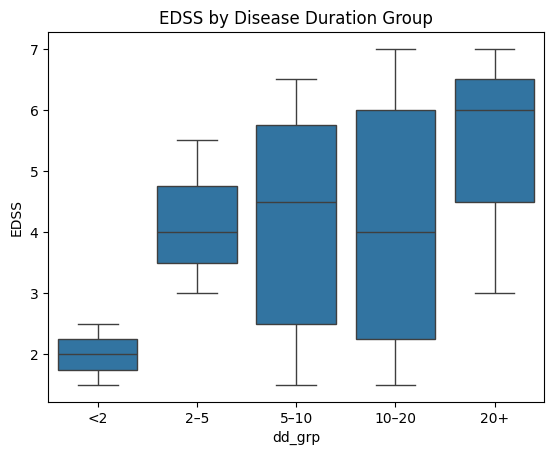

In [24]:
# === 10B. Demographic and clinical stratification (DD / EDSS) ===
# Patients only
# Group by dd (disease duration) and count
bins = [0, 2, 5, 10, 20, 100]
labels = ['<2', '2–5', '5–10', '10–20', '20+']
# Create a new column 'dd_grp' to categorize the disease duration
patients['dd_grp'] = pd.cut(patients['DD'], bins=bins, labels=labels)

# Show the counts of each group
print(patients['dd_grp'].value_counts())

# Visualization
sns.boxplot(x='dd_grp', y='EDSS', data=patients)
plt.title("EDSS by Disease Duration Group")
plt.show()


## Clinical Stratification: MS Type and Disease Duration

This section analyzes disease duration (`DD`) across different **Multiple Sclerosis (MS) subtypes**, providing insight into how progression may differ by clinical phenotype.

### MS Types Included:
- `RRMS`: Relapsing-Remitting MS
- `SPMS`: Secondary Progressive MS
- `PPMS`: Primary Progressive MS

These types are mapped from the `GROUP_MS` column, which uses short codes (`'RR'`, `'SP'`, `'PP'`).

### Steps:
- Converts MS subtype codes into readable labels.
- Counts the number of patients in each subtype group.
- Visualizes the distribution of **disease duration (DD)** across MS types using a boxplot.

**Example Code:**
```python
mstype_labels = {'RR': 'RRMS', 'SP': 'SPMS', 'PP': 'PPMS'}
patients['mstype_label'] = patients['GROUP_MS'].map(mstype_labels)

sns.boxplot(x='mstype_label', y='DD', data=patients)


C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\2725461024.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients['mstype_label'] = patients['GROUP_MS'].map(mstype_labels)


mstype_label
RRMS    30
SPMS    15
PPMS     7
Name: count, dtype: int64


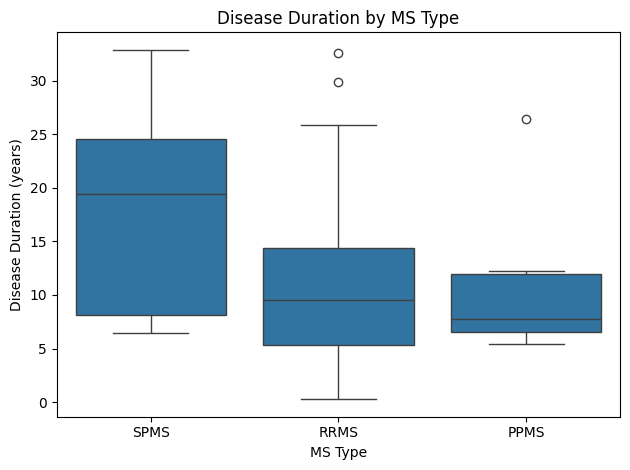

In [25]:
# === 10C. Demographic and clinical stratification (DD / MsType) ===
# Patients only
# Types EM: (0) RRMS, (1) SPMS y (2) PPMS
# 0 RRMS – Remitting-Relapsing 	
# 1 SPMS – Secondary Progressive 
# 2 PPMS – Primary Progressive 
# Map numerical MS types to readable labels
mstype_labels = {'RR': 'RRMS', 'SP': 'SPMS', 'PP': 'PPMS'}
patients['mstype_label'] = patients['GROUP_MS'].map(mstype_labels)

# Show count of each MS type
print(patients['mstype_label'].value_counts())

# Boxplot of disease duration by MS type
sns.boxplot(x='mstype_label', y='DD', data=patients)
plt.title("Disease Duration by MS Type")
plt.xlabel("MS Type")
plt.ylabel("Disease Duration (years)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Clinical Stratification: EDSS Severity Levels and Disease Duration

This section categorizes **patients** based on their **EDSS (Expanded Disability Status Scale)** scores, providing a clinical severity stratification. It then explores how disease duration (`dd`) varies across these severity levels.

### EDSS Severity Groups:
- `0–2`: Mild
- `2–4`: Moderate
- `4–6.5`: Moderate-Severe
- `6.5–9`: Severe
- `9–10`: Very Severe

### Steps:
- Bins EDSS scores into clinically meaningful categories.
- Counts the number of patients per severity group.
- Visualizes **disease duration** across EDSS severity groups using a boxplot.

**Example Code:**
```python
edss_bins = [0, 2, 4, 6.5, 9, 10]
edss_labels = ['0–2 (Mild)', '2–4 (Moderate)', '4–6.5 (Moderate-Severe)', '6.5–9 (Severe)', '9–10 (Very Severe)']
patients['edss_group'] = pd.cut(patients['edss'], bins=edss_bins, labels=edss_labels)

sns.boxplot(x='edss_group', y='dd', data=patients)


C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\816165560.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients['edss_group'] = pd.cut(patients['EDSS'], bins=edss_bins, labels=edss_labels)


📊 Patients per EDSS severity group:
edss_group
0–2 (Mild)                 10
2–4 (Moderate)             14
4–6.5 (Moderate-Severe)    25
6.5–9 (Severe)              3
9–10 (Very Severe)          0
Name: count, dtype: int64


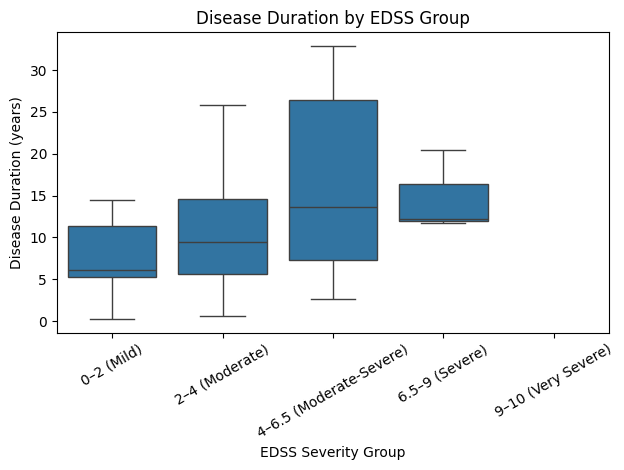

In [26]:
# === 10D. Demographic and clinical stratification (EDSS / Severity) ===
# Patients only
# Define EDSS severity bins
edss_bins = [0, 2, 4, 6.5, 9, 10]
edss_labels = [
    '0–2 (Mild)',
    '2–4 (Moderate)',
    '4–6.5 (Moderate-Severe)',
    '6.5–9 (Severe)',
    '9–10 (Very Severe)'
]

# Assign EDSS severity group
patients['edss_group'] = pd.cut(patients['EDSS'], bins=edss_bins, labels=edss_labels)

# Display group distribution
print("📊 Patients per EDSS severity group:")
print(patients['edss_group'].value_counts().sort_index())

# Visualize duration vs EDSS level
sns.boxplot(x='edss_group', y='DD', data=patients)
plt.title("Disease Duration by EDSS Group")
plt.xlabel("EDSS Severity Group")
plt.ylabel("Disease Duration (years)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Merge Clinical Stratification Variables into Main Clinical DataFrame

This step integrates the newly computed clinical stratification variables back into the main `clinic_df` DataFrame, ensuring that all relevant information is centrally available for downstream analysis or modeling.

### Variables Added:
- `dd_grp`: Disease duration group (binned)
- `mstype_label`: MS clinical subtype (`RRMS`, `SPMS`, `PPMS`)
- `edss_group`: EDSS-based severity group

### Process:
- Selects these columns from the `patients` DataFrame.
- Merges them into `clinic_df` by matching subject IDs.

**Example Code:**
```python
columns_to_add = ['dd_grp', 'mstype_label', 'edss_group']
clinic_df.loc[clinic_df.index.intersection(patients.index), columns_to_add] = (
    patients.loc[clinic_df.index.intersection(patients.index), columns_to_add]
)


In [27]:
# === 10E. Add clinical data to clinic_df ===
# Select columns to transfer from patients to clinic_df
columns_to_add = ['dd_grp', 'mstype_label', 'edss_group']

# Match and assign values where IDs are common
clinic_df.loc[clinic_df.index.intersection(patients.index), columns_to_add] = (
    patients.loc[clinic_df.index.intersection(patients.index), columns_to_add]
)

# Display result to confirm columns were added
print("✅ Columns successfully added to clinic_df:")
print(clinic_df[columns_to_add].info())


✅ Columns successfully added to clinic_df:
<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, sub-0001 to sub-0105
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   dd_grp        52 non-null     category
 1   mstype_label  52 non-null     object  
 2   edss_group    52 non-null     category
dtypes: category(2), object(1)
memory usage: 6.3+ KB
None


In [28]:
# Make sure 'Control' is added as a category before filling NaNs
for col in columns_to_add:
    if pd.api.types.is_categorical_dtype(clinic_df[col]):
        if 'Control' not in clinic_df[col].cat.categories:
            clinic_df[col] = clinic_df[col].cat.add_categories('Control')
            
# Now safely fill NaNs with 'Control'
clinic_df[columns_to_add] = clinic_df[columns_to_add].fillna('Control')

# Check result
print("✅ NaNs filled with 'Control' in categorical columns:")
print(clinic_df[columns_to_add].head())


✅ NaNs filled with 'Control' in categorical columns:
         dd_grp mstype_label               edss_group
ID                                                   
sub-0001   5–10         SPMS  4–6.5 (Moderate-Severe)
sub-0002   5–10         SPMS  4–6.5 (Moderate-Severe)
sub-0003     <2         RRMS               0–2 (Mild)
sub-0004  10–20         RRMS           2–4 (Moderate)
sub-0005   5–10         RRMS               0–2 (Mild)


C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\1539784892.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(clinic_df[col]):


## Compute and Visualize Group Mean Connectivity Matrices by Clinical Stratification

This section computes mean connectivity matrices for **custom-defined clinical subgroups**, such as disease duration (`dd_grp`), MS type (`mstype_label`), and EDSS severity (`edss_group`). It allows detailed subgroup-level analysis of brain connectivity.

---

### Function: `compute_group_mean_from_dataframe()`

Reconstructs full symmetric matrices from the vectorized DataFrame and computes a mean connectivity matrix per group based on a specified column from `clinic_df`.

- **Inputs:**
  - `vectors_df`: Corrected and masked vectorized connectivity matrices.
  - `clinic_df`: Clinical metadata including grouping column (e.g., `'dd_grp'`).
  - `group_col`: Column in `clinic_df` used to define groups.
  - `original_triu_idx`: Tuple with upper triangle indices.
  - `n_nodes`: Number of brain regions.

- **Output:**
  - Dictionary `{group_name: mean_connectivity_matrix}`

---

### Function: `plot_group_mean_matrices()`

Plots the heatmaps of mean matrices for each group using `matplotlib`.

- **Input:** Dictionary of mean matrices per group (from previous function).
- **Optional arguments:**
  - `title_prefix`: Text added before the group name in plot titles.
  - `cmap`: Colormap used for visualization (degmult: `'coolwarm'`).

---

### Example Applications:
```python
mean_matrices_dd = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)

plot_group_mean_matrices(mean_matrices_dd, title_prefix="Mean Connectivity (Median) - DD Group")


In [29]:
def compute_group_mean_from_dataframe(vectors_df, clinic_df, group_col, original_triu_idx, n_nodes=76):
    """
    Compute mean connectivity matrices from corrected vectorized DataFrame per group.

    Args:
        vectors_df (DataFrame): DataFrame with vectorized connectivity per subject.
        clinic_df (DataFrame): Clinical DataFrame with group information.
        group_col (str): Column in clinic_df to group by (e.g., 'dd_grp').
        original_triu_idx (tuple): Indices used in upper triangle vectorization.
        n_nodes (int): Number of regions (matrix size).

    Returns:
        dict: {group_name: mean_matrix (np.ndarray)}
    """
    total_connections = len(original_triu_idx[0])
    group_matrices = {}

    for group, group_df in clinic_df.groupby(group_col):
        subject_ids = group_df.index.intersection(vectors_df.index)

        matrices = []
        for subj in subject_ids:
            full_vector = np.zeros(total_connections)
            full_vector[list(vectors_df.columns)] = vectors_df.loc[subj].values

            matrix = np.zeros((n_nodes, n_nodes))
            matrix[original_triu_idx] = full_vector
            matrix = matrix + matrix.T
            matrices.append(matrix)

        if matrices:
            group_matrices[group] = np.mean(matrices, axis=0)
            print(f"✅ Group '{group}' → {len(matrices)} subjects")
        else:
            print(f"⚠️ Group '{group}' has no subjects with data")

    return group_matrices

# Mean matrices per disease duration group
mean_matrices_dd_median = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_dd_knn = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_knn_combat_masked,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_dd_median_re = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked_re,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_dd_knn_re = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_knn_combat_masked_re,
    clinic_df=clinic_df,
    group_col='dd_grp',
    original_triu_idx=triu_idx,
    n_nodes=76
)


# Mean matrices per MS type
mean_matrices_mstype_median = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked,
    clinic_df=clinic_df,
    group_col='mstype_label',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_mstype_knn = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_knn_combat_masked,
    clinic_df=clinic_df,
    group_col='mstype_label',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_mstype_median_re = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked_re,
    clinic_df=clinic_df,
    group_col='mstype_label',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_mstype_knn_re = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_knn_combat_masked_re,
    clinic_df=clinic_df,
    group_col='mstype_label',
    original_triu_idx=triu_idx,
    n_nodes=76
)

# Mean matrices per EDSS severity group
mean_matrices_edss_median = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked,
    clinic_df=clinic_df,
    group_col='edss_group',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_edss_knn = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_knn_combat_masked,
    clinic_df=clinic_df,
    group_col='edss_group',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_edss_median_re = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_median_combat_masked_re,
    clinic_df=clinic_df,
    group_col='edss_group',
    original_triu_idx=triu_idx,
    n_nodes=76
)
mean_matrices_edss_knn_re = compute_group_mean_from_dataframe(
    vectors_df=gm_vectors_knn_combat_masked_re,
    clinic_df=clinic_df,
    group_col='edss_group',
    original_triu_idx=triu_idx,
    n_nodes=76
)

def plot_multiple_group_mean_matrices(matrix_dicts, titles, cmap="coolwarm", n_cols=4):
    """
    Plot group mean matrices from multiple sources side-by-side.

    Args:
        matrix_dicts (list of dict): Each dict is {group_name: matrix}
        titles (list of str): One title per dict (e.g., Median, KNN, etc.)
        cmap (str): Colormap to use
        n_cols (int): How many matrices per row
    """
    import matplotlib.pyplot as plt

    # Detect all unique group names across all dictionaries
    all_groups = set()
    for d in matrix_dicts:
        all_groups.update(d.keys())
    all_groups = sorted(list(all_groups))

    n_rows = len(all_groups)
    n_total = len(matrix_dicts)

    fig, axes = plt.subplots(n_rows, n_total, figsize=(5 * n_total, 5 * n_rows))

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for row_idx, group in enumerate(all_groups):
        for dict_idx, matrix_dict in enumerate(matrix_dicts):
            ax = axes[row_idx, dict_idx]
            title_prefix = titles[dict_idx]

            if group in matrix_dict:
                matrix = matrix_dict[group]
                im = ax.imshow(matrix, cmap=cmap)
                ax.set_title(f"{title_prefix} - {group}")
                ax.set_xlabel("Region")
                ax.set_ylabel("Region")
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                ax.set_visible(False)  # Hide subplot if data is missing

    plt.tight_layout()
    plt.show()




✅ Group '<2' → 3 subjects
✅ Group '2–5' → 3 subjects
✅ Group '5–10' → 19 subjects
✅ Group '10–20' → 14 subjects
✅ Group '20+' → 13 subjects
✅ Group 'Control' → 53 subjects
✅ Group '<2' → 3 subjects
✅ Group '2–5' → 3 subjects
✅ Group '5–10' → 19 subjects
✅ Group '10–20' → 14 subjects


C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\3231091611.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in clinic_df.groupby(group_col):


✅ Group '20+' → 13 subjects
✅ Group 'Control' → 53 subjects
✅ Group '<2' → 3 subjects
✅ Group '2–5' → 3 subjects
✅ Group '5–10' → 19 subjects
✅ Group '10–20' → 14 subjects
✅ Group '20+' → 13 subjects
✅ Group 'Control' → 53 subjects
✅ Group '<2' → 3 subjects
✅ Group '2–5' → 3 subjects
✅ Group '5–10' → 19 subjects
✅ Group '10–20' → 14 subjects
✅ Group '20+' → 13 subjects
✅ Group 'Control' → 53 subjects
✅ Group 'Control' → 53 subjects
✅ Group 'PPMS' → 7 subjects
✅ Group 'RRMS' → 30 subjects
✅ Group 'SPMS' → 15 subjects
✅ Group 'Control' → 53 subjects
✅ Group 'PPMS' → 7 subjects
✅ Group 'RRMS' → 30 subjects
✅ Group 'SPMS' → 15 subjects
✅ Group 'Control' → 53 subjects
✅ Group 'PPMS' → 7 subjects
✅ Group 'RRMS' → 30 subjects
✅ Group 'SPMS' → 15 subjects
✅ Group 'Control' → 53 subjects
✅ Group 'PPMS' → 7 subjects
✅ Group 'RRMS' → 30 subjects
✅ Group 'SPMS' → 15 subjects
✅ Group '0–2 (Mild)' → 10 subjects
✅ Group '2–4 (Moderate)' → 14 subjects
✅ Group '4–6.5 (Moderate-Severe)' → 25 subjects
✅ 

C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\3231091611.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, group_df in clinic_df.groupby(group_col):


✅ Group '2–4 (Moderate)' → 14 subjects
✅ Group '4–6.5 (Moderate-Severe)' → 25 subjects
✅ Group '6.5–9 (Severe)' → 3 subjects
⚠️ Group '9–10 (Very Severe)' has no subjects with data
✅ Group 'Control' → 53 subjects
✅ Group '0–2 (Mild)' → 10 subjects
✅ Group '2–4 (Moderate)' → 14 subjects
✅ Group '4–6.5 (Moderate-Severe)' → 25 subjects
✅ Group '6.5–9 (Severe)' → 3 subjects
⚠️ Group '9–10 (Very Severe)' has no subjects with data
✅ Group 'Control' → 53 subjects


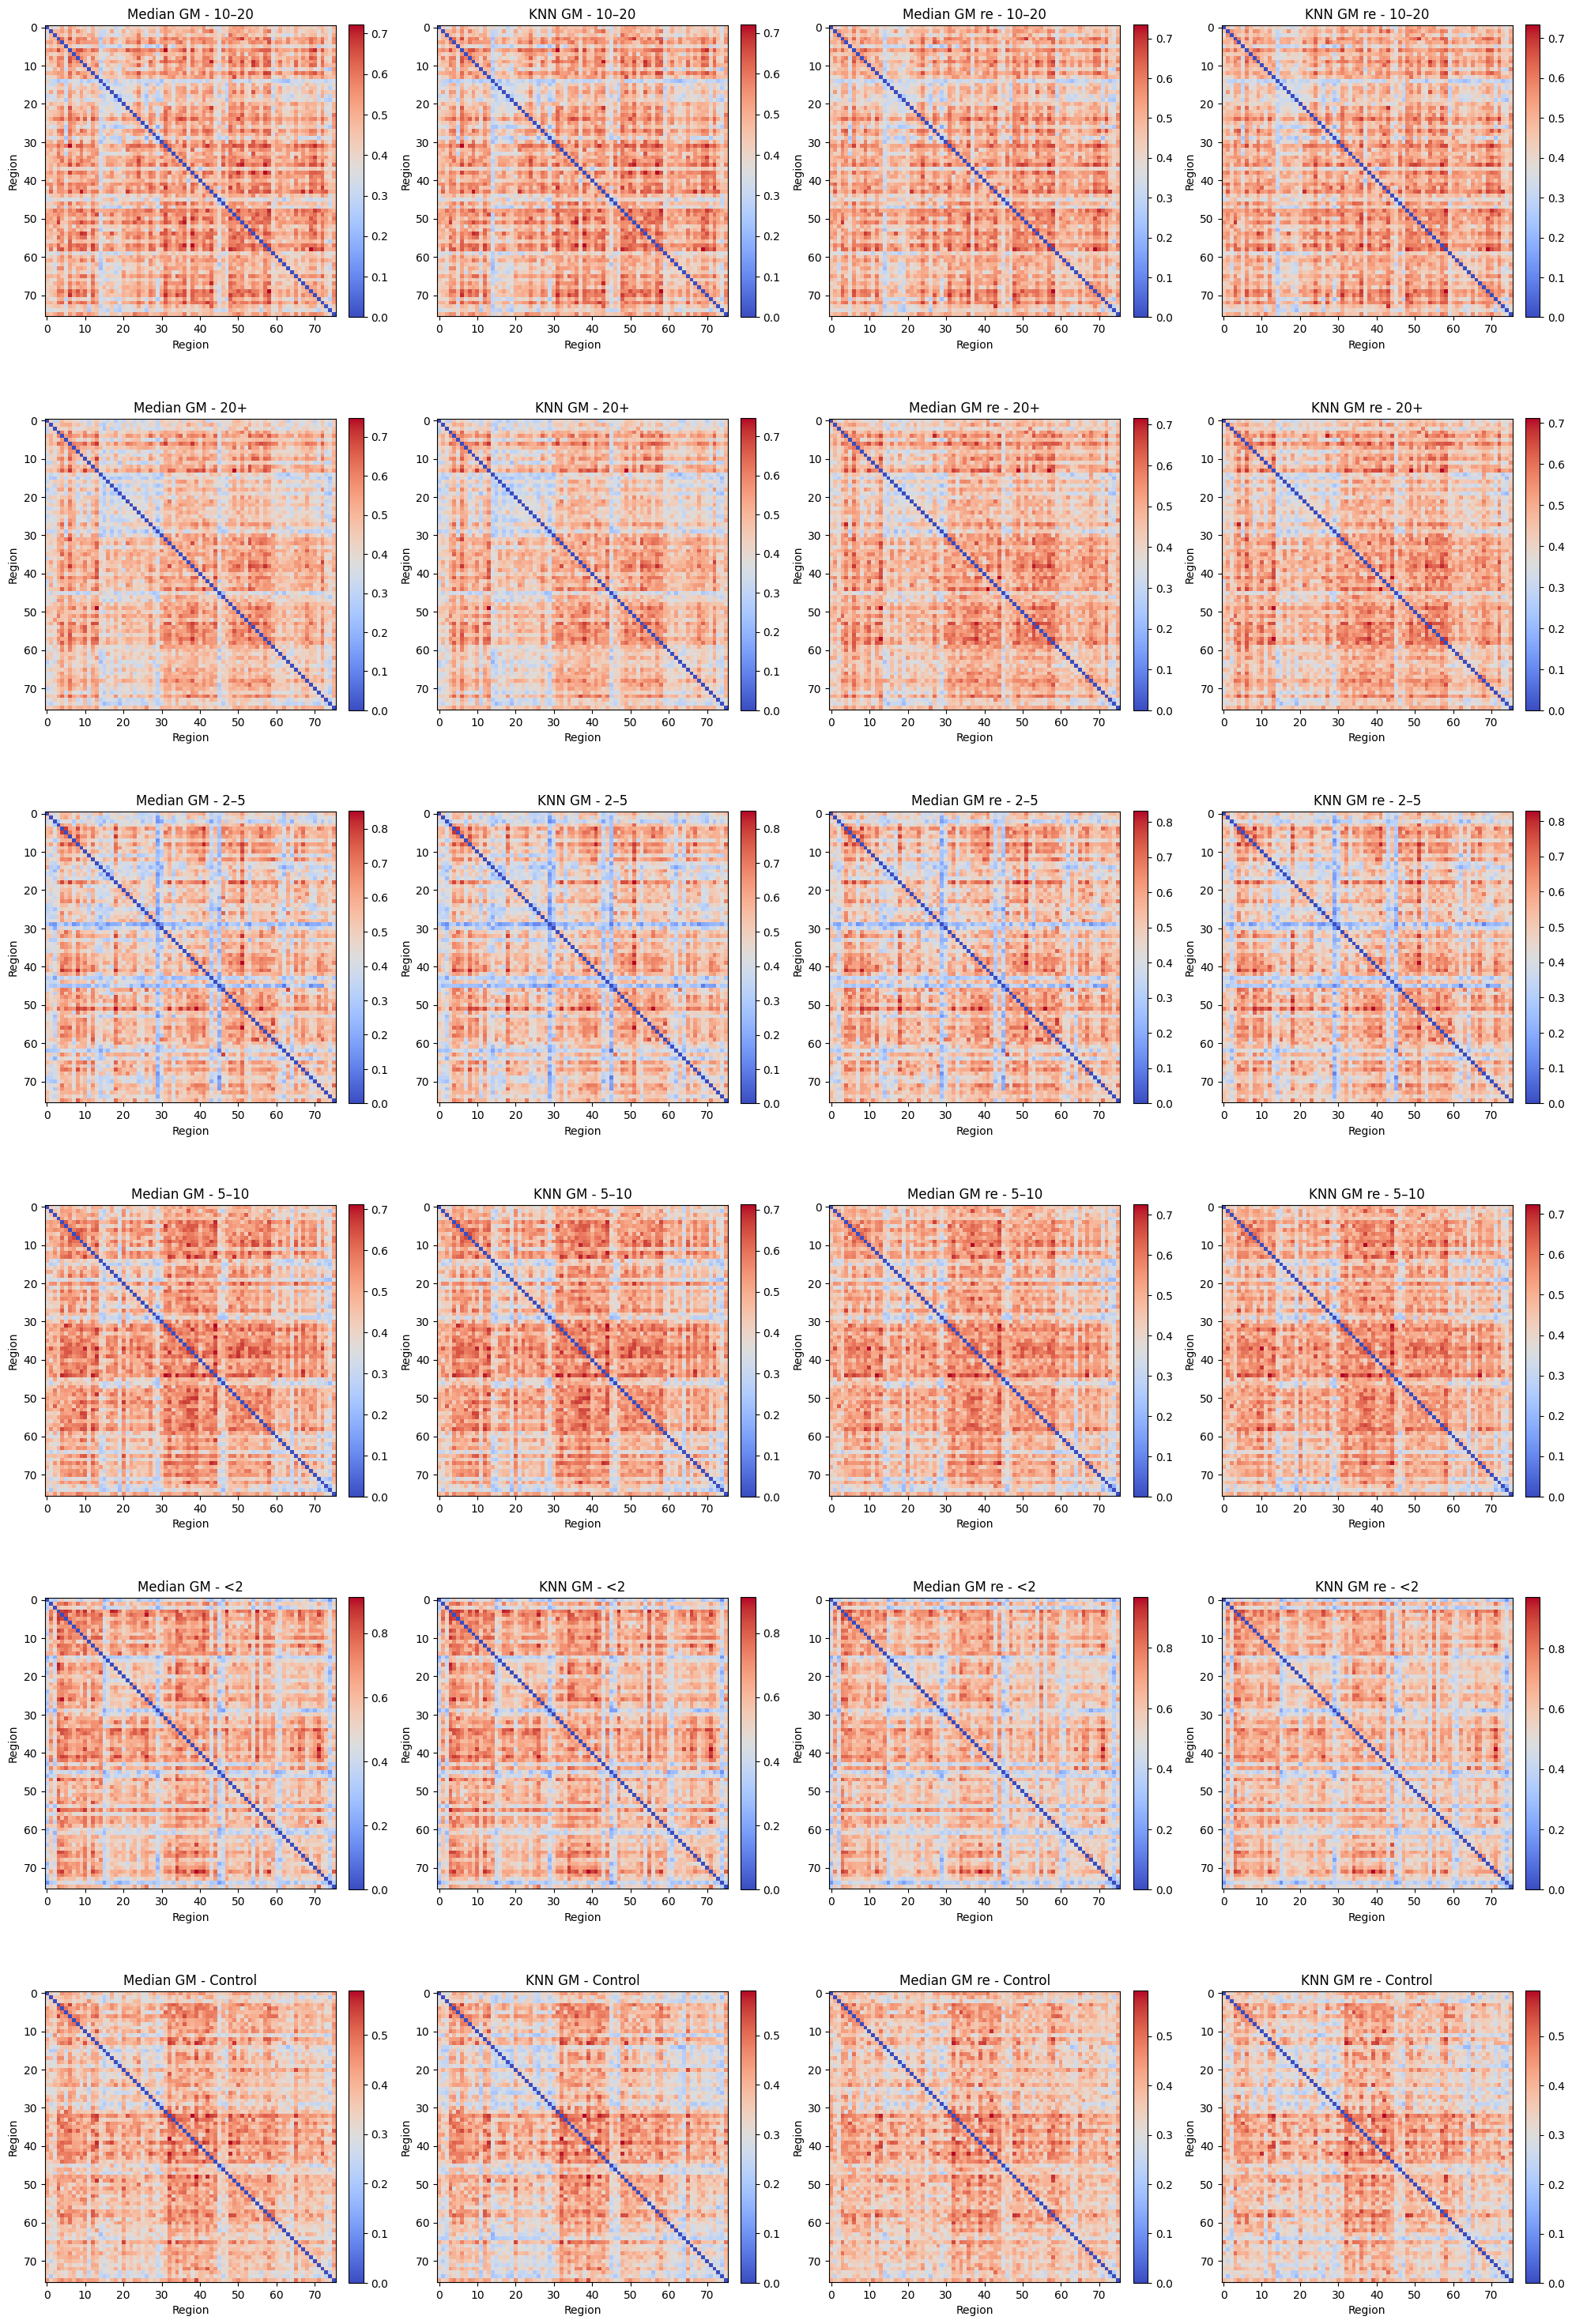

In [30]:
plot_multiple_group_mean_matrices(
    matrix_dicts=[
        mean_matrices_dd_median,
        mean_matrices_dd_knn,
        mean_matrices_dd_median_re,
        mean_matrices_dd_knn_re
    ],
    titles=[
        "Median GM",
        "KNN GM",
        "Median GM re",
        "KNN GM re"
    ],
    
)

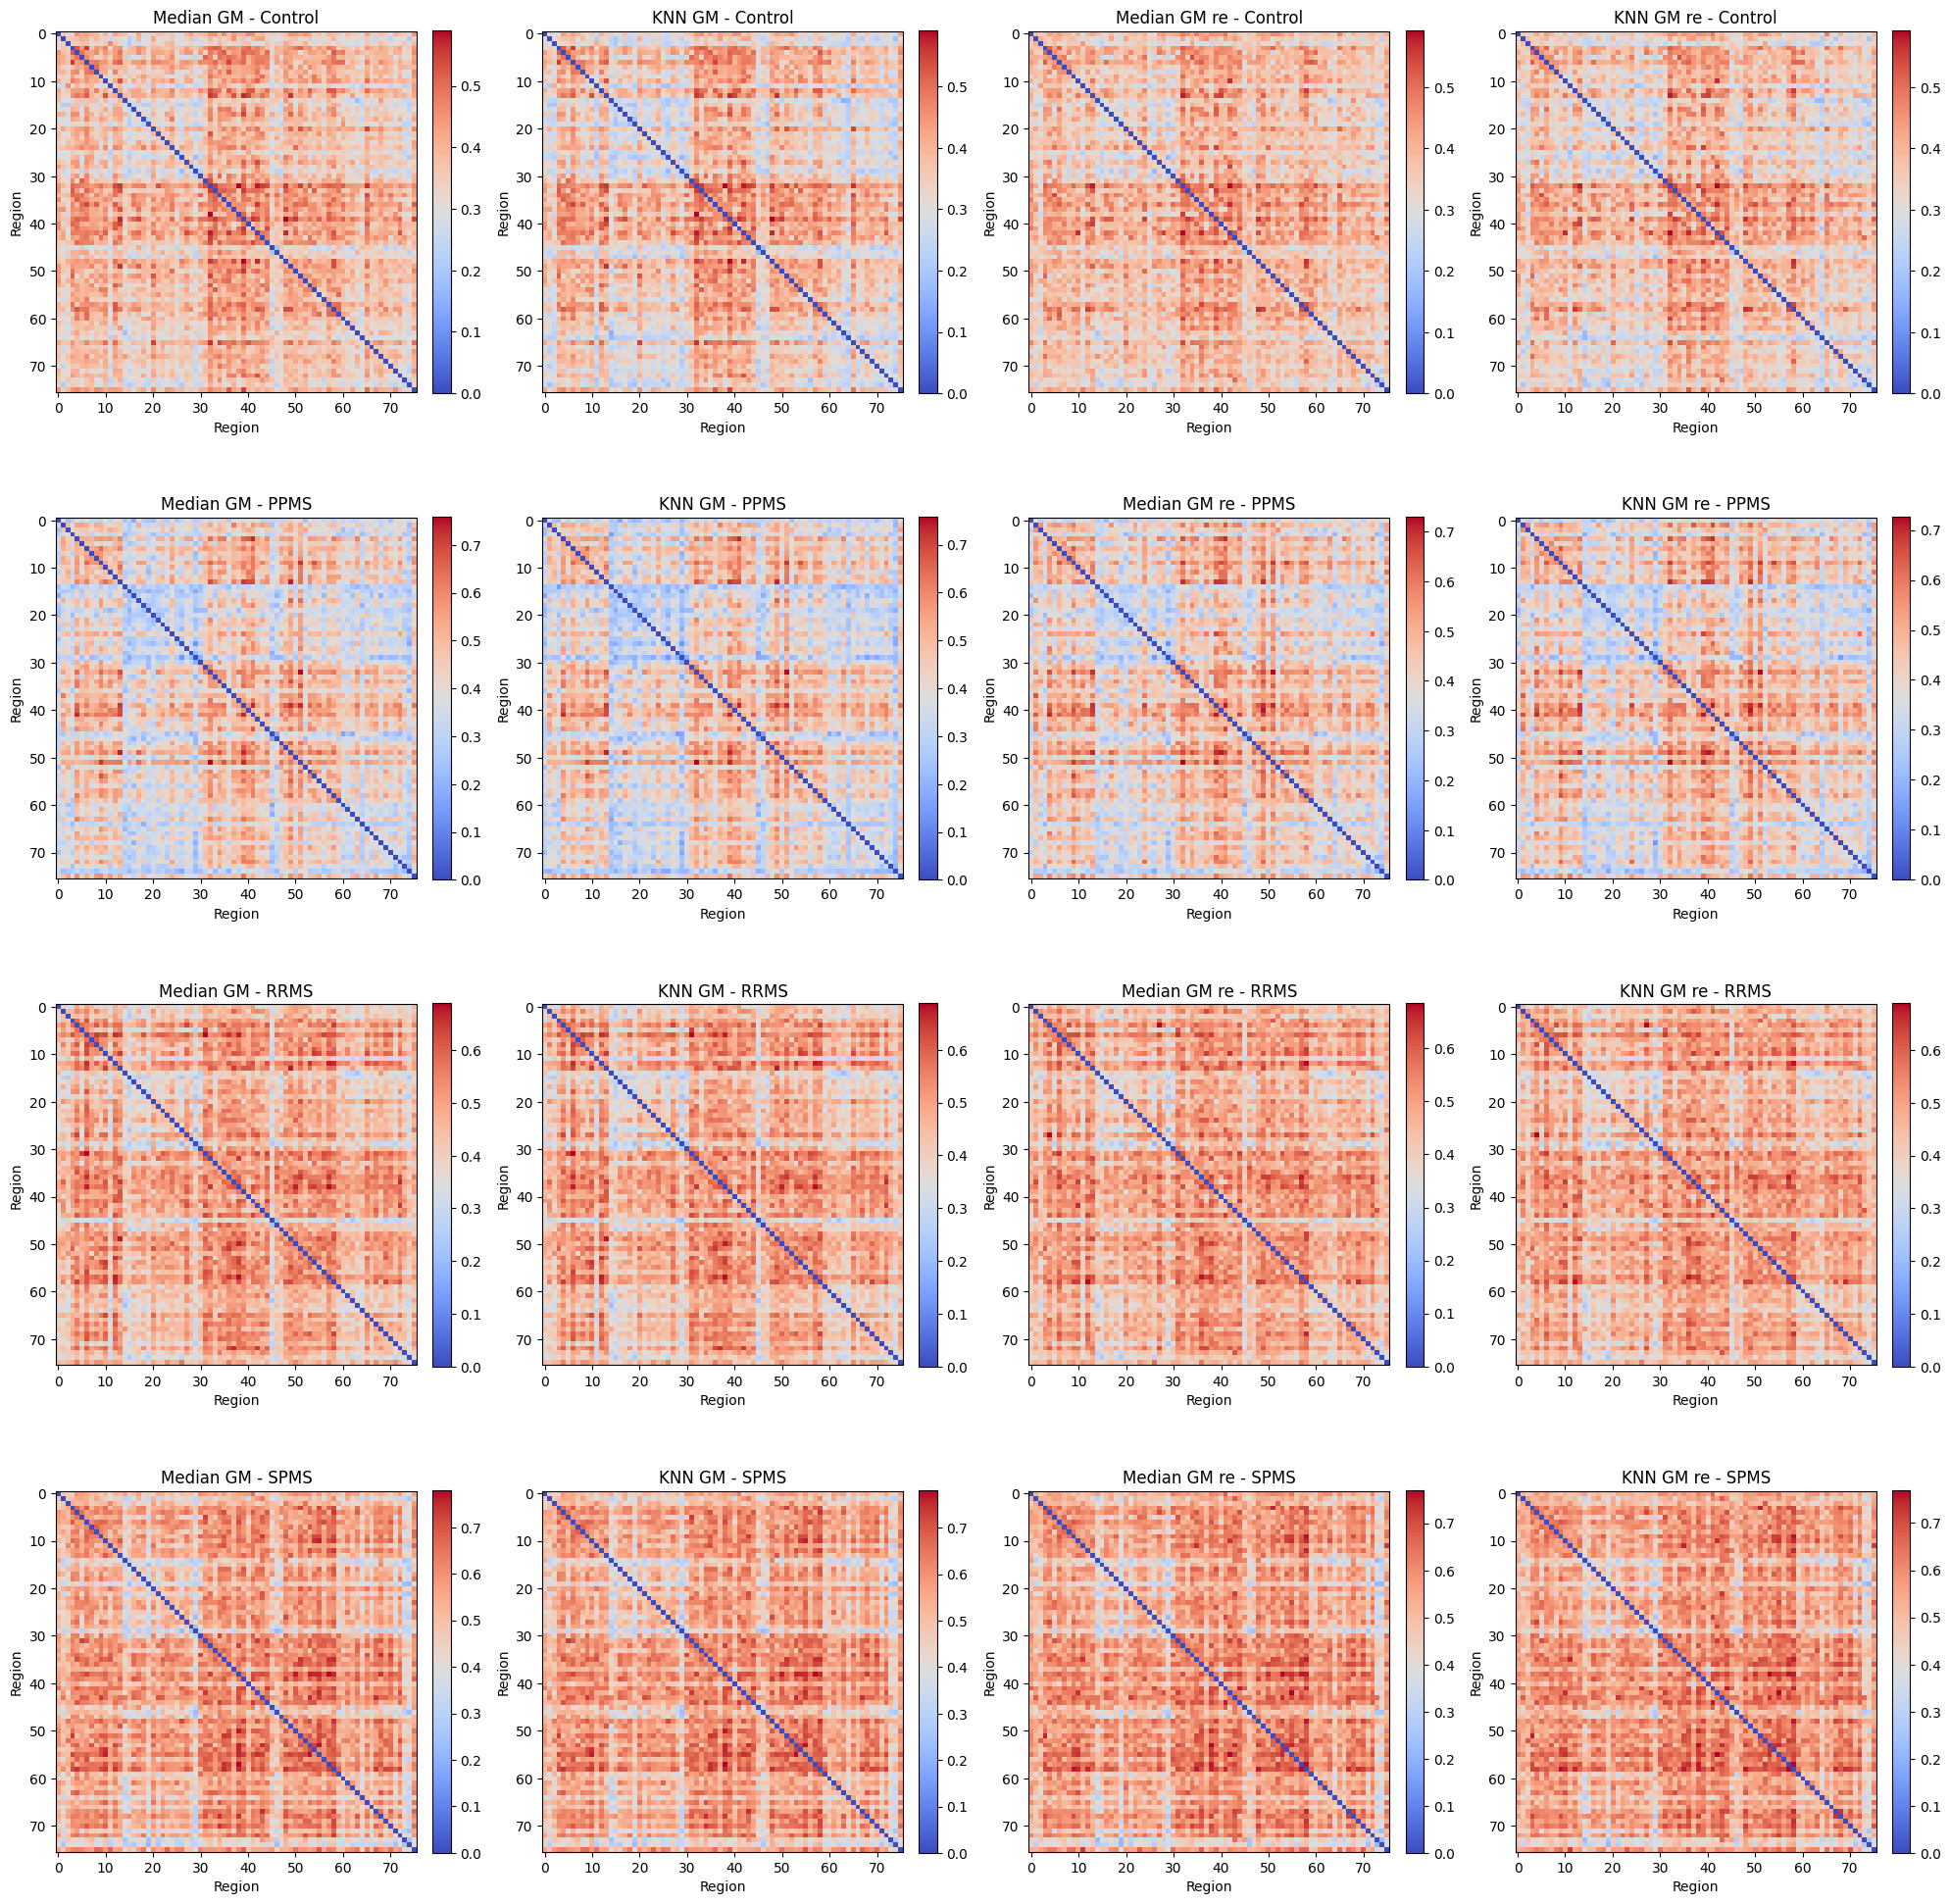

In [31]:
plot_multiple_group_mean_matrices(
    matrix_dicts=[
        mean_matrices_mstype_median,
        mean_matrices_mstype_knn,
        mean_matrices_mstype_median_re,
        mean_matrices_mstype_knn_re
    ],
    titles=[
        "Median GM",
        "KNN GM",
        "Median GM re",
        "KNN GM re"
    ],
 
)

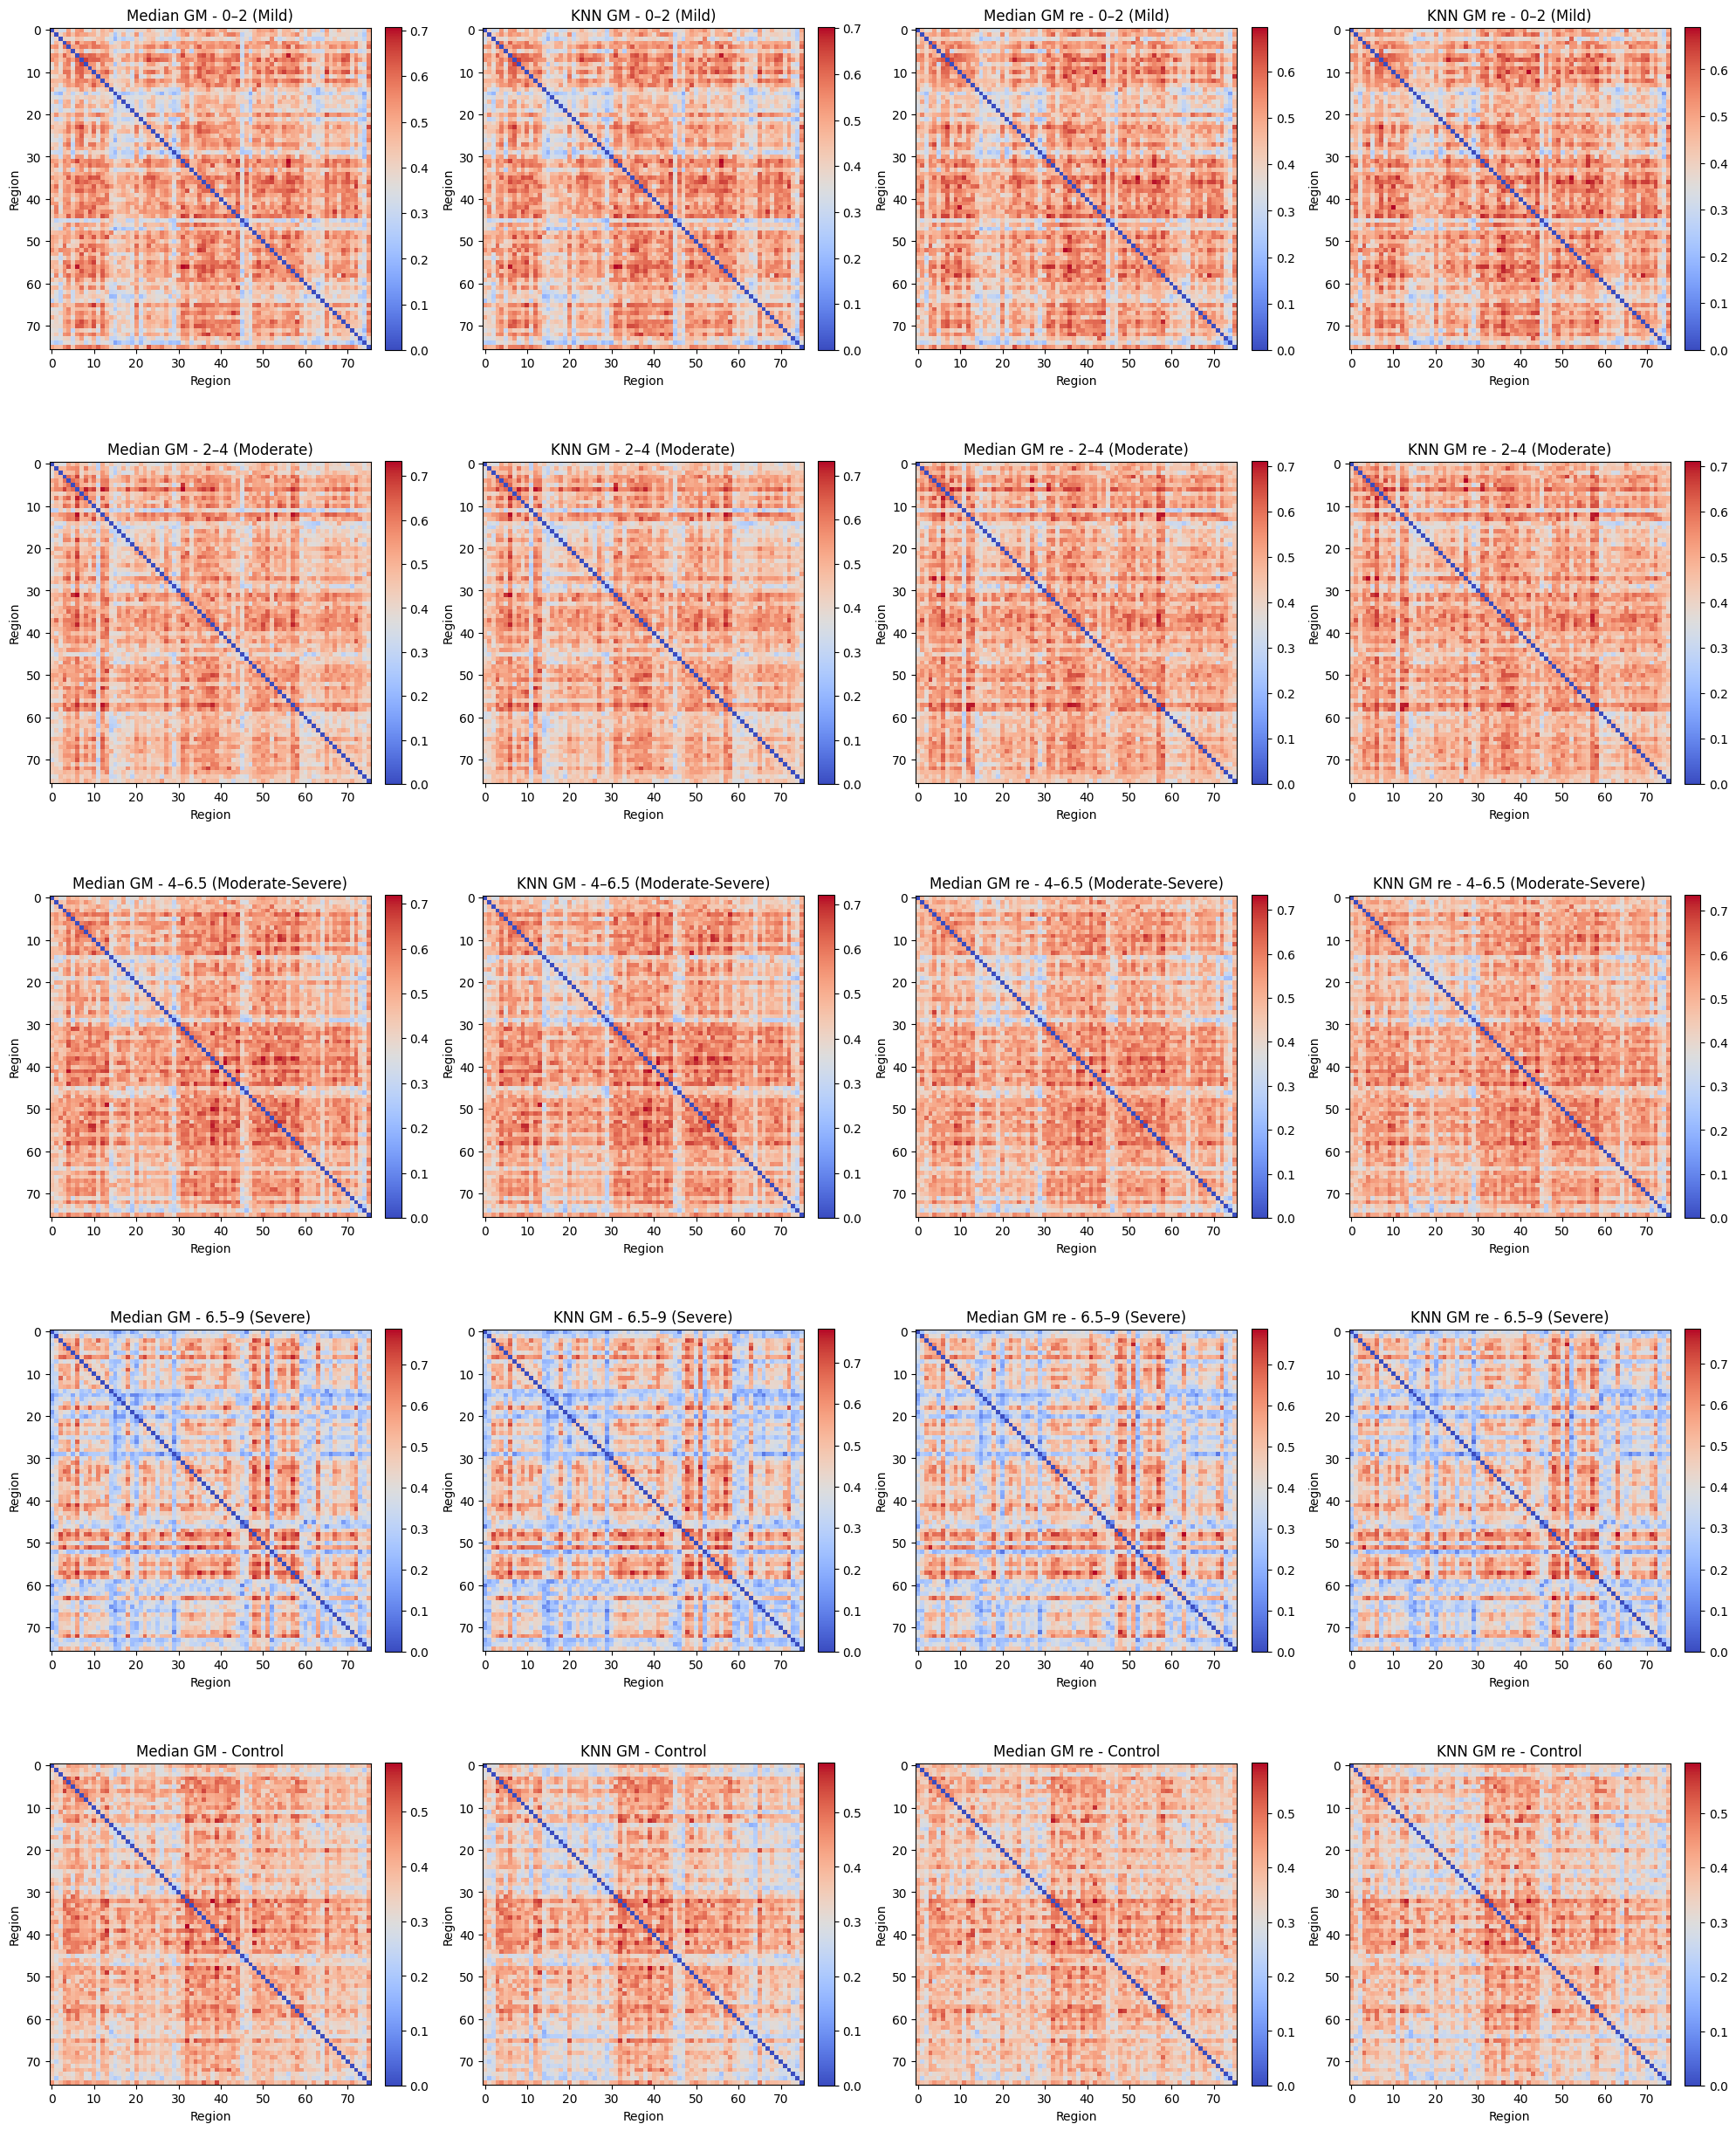

In [32]:
plot_multiple_group_mean_matrices(
    matrix_dicts=[
        mean_matrices_edss_median,
        mean_matrices_edss_knn,
        mean_matrices_edss_median_re,
        mean_matrices_edss_knn_re
    ],
    titles=[
        "Median GM",
        "KNN GM",
        "Median GM re",
        "KNN GM re"
    ],

)

## Save Subject Groupings and Summary Statistics

This section saves relevant summary information per disease duration group (`dd_grp`) to gmcilitate downstream analysis, documentation, or external use.

### Outputs:
1. **Subject Group Assignment CSV**  
   - Lists all patient IDs alongside their assigned disease duration group.
   - Format: one row per subject with columns: `dd_group`, `subject_id`.

2. **Group-Level Summary Statistics**  
   - Descriptive statistics (`mean`, `std`, `min`, `max`, etc.) for key clinical variables:
     - `age`, `sex`, `edss`, and `dd`
   - Computed separately per `dd_grp` group.
   - Saved as a multi-index CSV file.

**Example Code:**
```python
df_ids_by_duration.to_csv("output/ids_by_duration_ids.csv", index=False)
group_summary.to_csv("output/ids_by_duration_group_summary.csv")


In [33]:
# === 11. Save summary ===
# Group by dd_grp and collect subject IDs
ids_by_duration = patients.groupby('dd_grp').apply(lambda df: list(df.index))

# Convert to DataFrame (each row = one ID, with its group)
df_ids_by_duration = ids_by_duration.explode().reset_index()
df_ids_by_duration.columns = ['dd_group', 'subject_id']

# Save to CSV
df_ids_by_duration.to_csv(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_ids_by_duration_ids.csv",
    index=False
)

print("✅ Subject IDs per duration group saved successfully.")

# Grouped summary statistics per disease duration group
group_summary = patients.groupby('dd_grp')[['AGE', 'SEX', 'EDSS', 'DD']].describe()

# Export the full multi-level summary to CSV
group_summary.to_csv(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_ids_by_duration_group_summary.csv"
)

print("✅ Group summary statistics saved successfully.")


✅ Subject IDs per duration group saved successfully.
✅ Group summary statistics saved successfully.


C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\610443651.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ids_by_duration = patients.groupby('dd_grp').apply(lambda df: list(df.index))
C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\610443651.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ids_by_duration = patients.groupby('dd_grp').apply(lambda df: list(df.index))
C:\Users\alvar\AppData\Local\Temp\ipykernel_7172\610443651.py:18: FutureWarning: The default of observed=False is deprecated and will b

## Statistical Analysis Between Groups (Shapiro-Wilk, t-test, Mann-Whitney, Bonferroni)

This step performs a connection-wise statistical comparison between control and MS patient groups using the vectorized FA connectivity data. Each connection (i.e., each column in the DataFrame) is tested for significant group differences.

### Procedure:

1. **Group Labels:**
   - Subjects are labeled as `0` (Control) or `1` (MS Patient) using the `clinic_df['GROUP']` column.

2. **Loop Over Connections:**
   - For each connection:
     - Extract values for controls and patients.
     - Test for normality in each group using **Shapiro-Wilk**.
     - If both groups are normally distributed:
       - Use **independent t-test**.
     - Otherwise:
       - Use **Mann–Whitney U test** (non-parametric).

3. **Multiple Testing Correction:**
   - Raw *p*-values are corrected using **Bonferroni correction** (`alpha = 0.05`).

4. **Output:**
   - `FA_significant_connections.xlsx`: Only significant connections.
   - `FA_significant_padded_connections.xlsx`: Full matrix, with non-significant connections set to 0.

### Example Summary:
```python
p_values_clean = ...  # Raw p-values
reject, pvals_corrected = multipletests(p_values_clean, method="bonferroni")
significant_connections = p_values_clean.index[reject]

In [34]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# -------------------------
# Input data
# -------------------------
df_corrected = gm_vectors_median_combat_masked_re.copy()  # DataFrame with FA vectors per subject (105 x 2850)

# Align clinic_df to df_corrected subjects
#clinic_df = clinic_df.set_index("ID")
clinic_aligned = clinic_df.loc[df_corrected.index]

# Extract group labels (0 = Control, 1 = MS)
group_labels = clinic_aligned["GROUP"]

# -------------------------
# Initialize containers
# -------------------------
p_values = []
used_test = []

# -------------------------
# Loop through each connection
# -------------------------
for col in df_corrected.columns:
    control_values = df_corrected[group_labels == 0][col].dropna()
    patient_values = df_corrected[group_labels == 1][col].dropna()

    # Perform test only if both groups have at least 3 samples
    if len(control_values) >= 3 and len(patient_values) >= 3:
        # Shapiro-Wilk test for normality (α = 0.05)
        p_norm_control = shapiro(control_values)[1]
        p_norm_patient = shapiro(patient_values)[1]

        if p_norm_control > 0.05 and p_norm_patient > 0.05:
            # Both distributions are normal → use t-test
            p_val = ttest_ind(control_values, patient_values, equal_var=False)[1]
            used_test.append("t-test")
        else:
            # Non-normal distribution → use Mann-Whitney U test
            p_val = mannwhitneyu(control_values, patient_values, alternative='two-sided')[1]
            used_test.append("mannwhitney")
    else:
        p_val = np.nan
        used_test.append("insufficient")

    p_values.append(p_val)

# -------------------------
# Convert p-values to Series and apply Bonferroni correction
# -------------------------
p_values_series = pd.Series(p_values, index=df_corrected.columns)
used_test = pd.Series(used_test, index=df_corrected.columns)
p_values_clean = p_values_series.dropna()

# Bonferroni correction (α = 0.05)
reject, pvals_corrected, _, _ = multipletests(p_values_clean, alpha=0.05, method='bonferroni')

# -------------------------
# Extract significant connections
# -------------------------
significant_connections = p_values_clean.index[reject]
print(f"✅ Significant connections after Bonferroni: {len(significant_connections)}")

# -------------------------
# VERSION 1: Only significant connections
# -------------------------
significant_df = df_corrected[significant_connections]
significant_df.to_excel("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_significant_connections.xlsx", index=True)

# -------------------------
# VERSION 2: Full matrix with non-significant connections set to 0
# -------------------------
significant_padded_df = pd.DataFrame(0.0, index=df_corrected.index, columns=df_corrected.columns)
significant_padded_df.loc[:, significant_connections] = df_corrected[significant_connections]
significant_padded_df.to_excel("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_significant_padded_connections.xlsx", index=True)

# -------------------------
# Summary statistics for all 2850 connections
# -------------------------
stats_summary = pd.DataFrame({
    "p_raw": p_values_series,
    "test": used_test
})
stats_summary["p_corrected"] = np.nan
stats_summary.loc[p_values_clean.index, "p_corrected"] = pvals_corrected
stats_summary["significant"] = False
stats_summary.loc[significant_connections, "significant"] = True

stats_summary.to_excel(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/output/GM_significant_stats_summary.xlsx"
)

# -------------------------
# Preview results (optional)
# -------------------------
print("\n🔍 Preview of significant connections:")
display(significant_df.head())

print("\n🔍 Preview of padded matrix (non-significant = 0):")
display(significant_padded_df.head())

print("\n📊 Summary of all 2850 connections saved to: GM_significant_stats_summary.xlsx")

✅ Significant connections after Bonferroni: 262

🔍 Preview of significant connections:


,77,79,104,111,114,130,131,177,184,187,...,2654,2656,2661,2688,2691,2705,2708,2710,2816,2836
sub-0001,0.865295,0.736849,0.812672,1.000000,0.968710,0.836920,1.000000,0.089764,0.220077,0.209611,...,0.687088,0.669809,0.779169,0.505241,0.755692,0.805818,1.000000,0.965374,0.645790,0.756188
sub-0002,0.696654,0.784205,0.655335,0.717952,0.707624,0.553062,0.630914,0.391997,0.365505,0.423530,...,0.521780,0.430970,0.877326,0.445154,0.468474,0.631835,0.670329,0.455048,0.721074,0.487485
sub-0003,0.801657,0.626969,0.775744,0.888578,0.943475,0.841266,0.709526,0.561123,0.578297,0.570685,...,0.719571,0.545241,0.785602,0.827083,0.795320,0.789513,0.693483,0.708997,0.915143,0.608573
sub-0004,0.619455,0.711819,1.000000,0.976941,0.860712,1.000000,0.820283,0.604509,0.497173,0.360014,...,0.468563,0.458073,0.702819,0.934675,0.970281,0.768101,0.824787,0.828619,0.956616,1.000000
sub-0005,0.442539,0.663906,0.769123,0.643313,0.698573,0.459048,0.613275,0.327362,0.271390,0.335619,...,0.369862,0.277307,0.764712,0.522512,0.438415,0.742156,0.621276,0.549873,0.682299,0.437539



🔍 Preview of padded matrix (non-significant = 0):


,0,1,2,3,4,5,6,7,8,9,...,2840,2841,2842,2843,2844,2845,2846,2847,2848,2849
sub-0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sub-0002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sub-0003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sub-0004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sub-0005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



📊 Summary of all 2850 connections saved to: GM_significant_stats_summary.xlsx
